In [1]:
print('hello')

hello


---
# data

In [2]:
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device = u.Devices().auto_set_device()#drop=['cuda:4'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
) 

dataset = d.GraphDataset(brca, kegg, kegg)
_batch = d.get_toy_databatch(dataset, device)

('cuda:4', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:6', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:7', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:5', 'NVIDIA A100-SXM4-80GB', 74623)
('cuda:1', 'NVIDIA A100-SXM4-80GB', 65824)
('cuda:3', 'NVIDIA A100-SXM4-80GB', 63036)
('cuda:2', 'NVIDIA A100-SXM4-80GB', 43110)
('cuda:0', 'NVIDIA A100-SXM4-80GB', 31616)

# #### Device() ####
# device = cuda:4

# #### KEGG() ####
# _orig_kwargs             5                        dict
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:4)
# edge_attr                (32464, 16)              Tensor (cuda:4)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:4)

# #### TCGA() ####
# _orig_kwargs             9                        dict
# counts_path            

---
# model and output values

In [3]:
from modules.train import Loader
from modules.data import GraphDataset

from torch_geometric.loader import DataLoader
from modules.data import GraphDataset
from modules.utils import dict_summary
from collections import defaultdict

# typing
import torch
import torch.nn as nn
from torch import Tensor
from torch_geometric.data import Data, Batch


In [4]:
def load_model(model, state_dict_path:str, device:str, dataset:GraphDataset|None=None, batch_size:int=128):
    # init with loader
    init_fn = getattr(model, 'init_with_loader', None)
    if callable(init_fn) and dataset is not None:
        loader = Loader(dataset, device=device, batch_size=batch_size)
        init_fn(loader)

    # load state dict
    state_dict = torch.load(state_dict_path, map_location=device)
    model.load_state_dict(state_dict)

    # set model to eval
    model.eval()   

In [5]:
class ModelOut2():
    def __init__(self, model:nn.Module, dataset:GraphDataset, batch_size:int=64, **fwd_kwargs):
        fwd_kwargs = fwd_kwargs if fwd_kwargs is not None else {}

        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

        x_list = []
        y_list = []
        out_list = []

        for batch in loader:
            out = model(batch, **fwd_kwargs)
            out = self._detach_items(out)
            out_list.append(out)
            x_list.append(batch.x)
            y_list.append(batch.y)

        self.x = torch.cat(x_list, dim=0).reshape(-1, dataset.wrapper.num_nodes).cpu()
        self.y = torch.cat(y_list, dim=0).cpu()
        self.out = self._transpose_values(out_list)

    def _detach_items(self, item):
        # single tensor
        if isinstance(item, Tensor):
            return item.detach().cpu()

        # list/tuple (recursive)
        if isinstance(item, (list, tuple, set)):
            return type(item)(self._detach_items(i) for i in item)

        # dict, PyG Data/DataBatch
        if isinstance(item, (dict, Data, Batch)):
            return {key: self._detach_items(value) for key, value in item.items()}
        
        # other class with .x
        if hasattr(item, 'x'):
            return {
                'x': self._detach_items(item.x),
                'y': self._detach_items(getattr(item, 'y', None)),
                'sample_id': self._detach_items(getattr(item, 'sample_id', None))
            }
        
        # fallback
        return item

    def _transpose_values(self, values) -> dict:
        out = defaultdict(list)

        # collect
        for v in values:
            for k, val in v.items():
                out[k].append(val)

        # concat if tensor
        for k, vals in out.items():
            v0 = vals[0]

            if torch.is_tensor(v0):
                if v0.ndim == 0: # scalar tensor -> stack
                    out[k] = torch.stack(vals, dim=0)

                # elif v0.ndim == 1: # vector tensor -> concat

                else: # batched tensor -> concat on batch dim
                    out[k] = torch.cat(vals, dim=0)
            
            elif isinstance(v0, dict): # dict -> recursively concat
                out[k] = self._transpose_values(vals)

            else:
                out[k] = vals

        return dict(out) 

---
# multi-trial output values

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from tqdm import tqdm
import math

In [7]:
# for model
from modules.layers import AttentionSetPooling
from modules.model import MultiLatentModel
from modules.norm import LogCounts
from modules.train import MultiTrainer, MultiTrainerStage, Experiment, grid, Loader
from modules.trainers import ReconstrTrainer, ClassifTrainer
from modules.loss import NBLoss, KLDLoss, MultiLoss

import torch
import torch.nn as nn
from functools import partial

In [8]:
class AttnOut():
    def __init__(self, dataset, model_dirs:list[str], pathway_names_dir:str, mode:str['ae','cl']='ae'):
        self.dataset = dataset
        self.mode:str = mode

        # from dataset
        self.y = dataset.wrapper.y.cpu()
        self.y_labels = dataset.wrapper.y_labels
        self.x_labels = dataset.wrapper.x_labels
        self.pathway_index = dataset.wrapper.pathway_index

        # pathway labels
        self.pathway_labels = [s.replace('path:', '') for s in dataset.wrapper.pathway_labels]
        self.pathway_names = pd.read_csv(pathway_names_dir, index_col=0).loc[self.pathway_labels, 'name'].str.replace(' - Homo sapiens (human)', '').to_list()

        # get values
        self._get_vals(model_dirs)

    def _get_vals(self, model_dirs:list[str]):
        joint_list:list = []
        # np_list: list = []

        for model_name in tqdm(model_dirs):
            # define model
            model = MultiLatentModel(
                dataset = self.dataset,
                embed_dim = 128,
                # head_dim = None (default)
                # num_heads = 1 (default)
                method = 'set',

                # layers
                norm_class = LogCounts,
                encoder_class = nn.Linear,
                pooling_class = AttentionSetPooling,
                mlp = False,
                variational = True,
                # out_module = nn.Linear (default)

                # layer params
                hidden_dims = 1,
                act_fn = nn.ReLU, 
                norm_fn = 'layer', 
                end_fn = False,

                # kwargs
                norm_kwargs = {'libnorm':True, 'znorm':True, 'learnable':True}
                # pooling_kwargs = None (default)
            )

            load_model(
                model=model,
                # state_dict_path=f'output/2026-01-20_18h51m04s_benchmark_2_attn/pathway_vae/{model_name}', # range = 5
                state_dict_path=model_name, # range = 30
                device=device,
                dataset=self.dataset,
            )

            # get output values
            vals = ModelOut2(model, self.dataset, need_weights=True)

            np = vals.out['layer_outs']['np']['attn'] # 1172,4373,305
            lp = vals.out['layer_outs'][f'lp_{self.mode}']['attn'].squeeze() # 1172,305
            joint = lp.unsqueeze(1) * np # 1172,4373,305

            # append to list
            joint_list.append(joint)
            # np_list.append(np)

        # stack tensors
        self.joint = torch.stack(joint_list, dim=0)
        # self.np = torch.stack(np_list, dim=0)


---
# helper functions

In [9]:
def group_by_class(data:Tensor, labels:Tensor, dim=1) -> dict[int, Tensor]:
    
    # temporarily move class dim to front for easier indexing
    data_temp = data.movedim(dim, 0)

    grouped = {}
    for c in labels.unique():
        grouped[int(c)] = data_temp[labels == c]
        grouped[int(c)] = grouped[int(c)].movedim(0, dim) # move class dim back to original position

    return grouped

In [10]:
def get_rankings(
    joint: torch.Tensor,            # (trials, samples, genes, pathways)
    gene_labels: list[str],
    class_tensor: Tensor,           # (samples,)
    class_labels: list[str],
    pathway_names: list[str],
    pathway_index: torch.Tensor,    # (genes, pathways)
    level: str['pathway', 'gene'] = 'pathway',
    balanced: bool = True,
    frac: float = 0.3,
    eps: float = 1e-8,
):
    # sum on genes if pathway, else sum on pathways if gene
    sum_means_on = 2 if level == 'pathway' else 3
    sum_idx_on = 0 if level == 'pathway' else 1
    
    # class means
    class_trial_means = {}
    class_means = []

    split = group_by_class(joint, class_tensor, dim=1)
    for class_idx, tensor in split.items():
        # get class name from label
        class_name = class_labels[class_idx]

        # sum across genes: (trials, samples_c, pathways) -> mean across samples: (trials, pathways)
        class_trial_mean = tensor.sum(dim=sum_means_on).mean(dim=1)   

        # store means for later
        class_trial_means[class_name] = class_trial_mean
        class_means.append(class_trial_mean.mean(dim=0)) # (pathways,)

    # global mean & df
    if balanced:
        # (trials, pathways) -> mean across trials: (pathways,)
        global_mean = torch.stack(class_means, dim=0).mean(dim=0) # (pathways,)

        # (classes, trials, pathways) -> mean across classes: (trials, pathways) -> std across trials: (pathways,)
        global_std = torch.stack([v for v in class_trial_means.values()], dim=0).mean(dim=0).std(dim=0, unbiased=False)

    else:
        # sum across genes: (trials, samples, pathways) -> mean across samples: (trials, pathways)
        trial_means = joint.sum(dim=sum_means_on).mean(dim=1) # (trials, pathways)

        # mean/std across trials: (pathways,)
        global_mean = trial_means.mean(dim=0)
        global_std = trial_means.std(dim=0, unbiased=False)

    # build dataframe
    df = pd.DataFrame({
        "name": pathway_names if level == 'pathway' else gene_labels,
        "n": pathway_index.sum(dim=sum_idx_on).detach().cpu().numpy(), # sum across genes: (pathways,)
        "global_mean": global_mean.detach().cpu().numpy(),
        "global_std": global_std.detach().cpu().numpy(),
    })

    # add class-specific mean columns
    df_classes = pd.DataFrame({"name": pathway_names if level == 'pathway' else gene_labels})
    for class_name, class_trial_mean in class_trial_means.items():
        df_classes[class_name] = class_trial_mean.mean(dim=0).detach().cpu().numpy()

    # lowess size correction
    if level == 'gene': # add jitter to remove duplicate values warning
        x = df["n"].values + np.random.normal(0, 1e-8, size=df["n"].values.shape)
    else:
        x = df["n"].values

    df["lowess_expected"] = sm.nonparametric.lowess(
        df["global_mean"].values, # y
        x,
        frac=frac,
        return_sorted=False
    )
    df["lowess_resid"] = df["global_mean"] - df["lowess_expected"]
    df["score"] = df["lowess_resid"] / (df["global_std"] + eps)

    return df, df_classes

In [11]:
def plot_x_effect(
    df:pd.DataFrame,
    x:str='n',
    lowess:bool=False,
    figsize:tuple=(12,18),
    sharex:bool=True,
):
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=sharex)

    # global mean
    sns.scatterplot(data=df, x=x, y="global_mean", ax=axes[0])
    if lowess:
        sns.lineplot(data=df, x=x, y="lowess_expected", ax=axes[0], color='red')
        axes[0].legend(
            handles=[axes[0].collections[0], axes[0].lines[0]], 
            labels=["Global mean", "LOWESS expected"], 
            loc="best"
        )
    
    # lowess residuals
    sns.scatterplot(data=df, x=x, y="lowess_resid", ax=axes[1])
    axes[1].axhline(0, color='red', linestyle='--')

    # score
    sns.scatterplot(data=df, x=x, y="score", ax=axes[2])
    axes[2].axhline(0, color='red', linestyle='--')

    plt.show()



In [12]:
def class_rank(
    df:pd.DataFrame, 
    df_classes:pd.DataFrame, 
    by:str['global_mean','lowess_resid','score'],
    value:str['global_mean','lowess_resid','score'],
    y_labels:list[str]|None=None,
):
    plot_df = df_classes.copy()
    plot_df = plot_df.loc[df.sort_values(by, ascending=False).index]

    if value == 'lowess_resid':
        y_labels = plot_df.columns.difference(['name'])
        plot_df[y_labels] = plot_df[y_labels].sub(df['lowess_expected'], axis=0)

    if value == 'score':
        y_labels = plot_df.columns.difference(['name'])
        plot_df[y_labels] = plot_df[y_labels].sub(df['lowess_expected'], axis=0).div(df['global_std'] + 1e-8, axis=0)

    plot_df['Global'] = df[value]

    return plot_df

In [13]:
def plot_topk_pathway_heatmap(
    df:pd.DataFrame, 
    top_k:int=10,
    center:bool=True,
    quantile_clip:float=0.99,
):
    if not center:
        vmin = 0
        vmax = df['Global'].quantile(quantile_clip)
        center = None
    else:
        vmin = -df['Global'].abs().quantile(quantile_clip)
        vmax = df['Global'].abs().quantile(quantile_clip)
        center = 0

    fig, axes = plt.subplots(1, 2, figsize=(16, 0.2 * top_k + 2))

    # local heatmap
    sns.heatmap(
        df.set_index('name').head(top_k),
        center=center,
        vmin=vmin, 
        vmax=vmax,
        ax=axes[0],
        cbar=False
    )
    pos = df.columns.get_loc("Global")
    axes[0].vlines(pos - 1, *axes[0].get_ylim(), color='white', linewidth=3)
    axes[0].set_ylabel('Pathways')
    axes[0].tick_params(axis="x", labelrotation=330)

    # global heatmap
    sns.heatmap(
        df.set_index('name'),
        center=center,
        vmin=vmin, 
        vmax=vmax,
        ax=axes[1],
        yticklabels=False
    )
    pos = df.columns.get_loc("Global")
    axes[1].vlines(pos - 1, *axes[1].get_ylim(), color='white', linewidth=3)
    axes[1].set_ylabel('Pathways')
    axes[1].tick_params(axis="x", labelrotation=330)

    plt.show()

In [14]:
def plot_pathway_heatmaps_by_quant(
    df: pd.DataFrame,
    quantile_clips: list[float] = [0.95, 0.99],
    center: bool = True,
    subplots_per_line: int = 3,
    subplot_width: int = 6,
    subplot_height: int = 8,
):
    n = len(quantile_clips)
    ncols = min(subplots_per_line, n)
    nrows = math.ceil(n / subplots_per_line)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(subplot_width * ncols, subplot_height * nrows),
        sharex=True,
        squeeze=False
    )

    heatmap_df = df.set_index("name")
    pos = df.columns.get_loc("Global")

    for i, quantile_clip in enumerate(quantile_clips):
        ax = axes[i // subplots_per_line, i % subplots_per_line]

        if not center:
            vmin = 0
            vmax = df["Global"].quantile(quantile_clip)
            center_val = None
        else:
            vmax = df["Global"].abs().quantile(quantile_clip)
            vmin = -vmax
            center_val = 0

        sns.heatmap(
            heatmap_df,
            center=center_val,
            vmin=vmin,
            vmax=vmax,
            ax=ax,
            yticklabels=False,
        )

        ax.vlines(pos - 1, *ax.get_ylim(), color="white", linewidth=3)
        ax.set_title(f"Quantile clip: {quantile_clip}")
        ax.set_ylabel("Pathways" if i % subplots_per_line == 0 else "")
        # ax.tick_params(axis="x", labelrotation=330)

    # Hide unused axes
    for j in range(n, nrows * ncols):
        axes[j // subplots_per_line, j % subplots_per_line].axis("off")

    plt.tight_layout()
    plt.show()

In [15]:
def plot_topk_pathway_bar(
    df:pd.DataFrame, 
    top_k:int=10,
    col:str='Global',
    hist:bool=True,
):
    df = df.copy()
    df = df.loc[df.sort_values(col, ascending=False).index]
    if hist:
        fig, axes = plt.subplots(1, 2, figsize=(16, 0.2 * top_k + 2))
        sns.barplot(x=col, y='name', data=df.head(top_k), ax=axes[0])
        sns.histplot(df[col], kde=True, ax=axes[1])
    else:
        plt.figure(figsize=(10, 0.2 * top_k + 2))
        sns.barplot(x=col, y='name', data=df.head(top_k))
    plt.tight_layout()
    plt.show()

---

In [16]:
def top_genes_per_pathway(
    joint: torch.Tensor,              # (trials, samples, genes, pathways)
    gene_labels: list[str],
    class_tensor: torch.Tensor,       # (samples,)
    class_labels: list[str],
    pathway_names: list[str],
    pathway_index: torch.Tensor,      # (genes, pathways)
    query_pathways: list[str],
    top_k: int = 20,
    balanced: bool = True,
    include_class_specific: bool = True,
):
    T, N, G, P = joint.shape

    device = joint.device
    class_tensor = class_tensor.to(device)
    pathway_index = pathway_index.to(device).bool()

    pathway_to_idx = {name: i for i, name in enumerate(pathway_names)}

    rows = []

    for pathway_name in query_pathways:
        if pathway_name not in pathway_to_idx:
            raise ValueError(f"Pathway not found: {pathway_name}")

        p_idx = pathway_to_idx[pathway_name]

        # Only genes that belong to this pathway
        gene_idx = torch.where(pathway_index[:, p_idx])[0]

        if gene_idx.numel() == 0:
            continue

        # (trials, samples, genes_in_pathway)
        attn = joint[:, :, gene_idx, p_idx]

        # --------------------------------------------------
        # Class-specific summaries
        # --------------------------------------------------
        class_gene_means = {}
        class_gene_stds = {}

        for class_idx, class_name in enumerate(class_labels):
            sample_mask = class_tensor == class_idx

            if sample_mask.sum() == 0:
                continue

            # (trials, samples_in_class, genes_in_pathway)
            class_attn = attn[:, sample_mask, :]

            # mean over trials and samples
            class_mean = class_attn.mean(dim=(0, 1))
            class_std = class_attn.std(dim=(0, 1), unbiased=False)

            class_gene_means[class_name] = class_mean
            class_gene_stds[class_name] = class_std

            if include_class_specific:
                order = torch.argsort(class_mean, descending=True)

                for rank, local_i in enumerate(order[:top_k], start=1):
                    g_idx = gene_idx[local_i].item()

                    rows.append({
                        "pathway": pathway_name,
                        "class": class_name,
                        "ranking_type": "class_specific",
                        "rank": rank,
                        "gene": gene_labels[g_idx],
                        "gene_idx": g_idx,
                        "pathway_idx": p_idx,
                        "mean_attention": class_mean[local_i].item(),
                        "std_attention": class_std[local_i].item(),
                        "n_pathway_genes": gene_idx.numel(),
                        "gene_pathway_degree": pathway_index[g_idx].sum().item(),
                    })

        # --------------------------------------------------
        # Global summary
        # --------------------------------------------------
        if balanced:
            # Macro-average across classes
            # Each class contributes equally
            global_mean = torch.stack(
                list(class_gene_means.values()), dim=0
            ).mean(dim=0)

            # Trial-level macro mean for std
            trial_class_means = []

            for class_idx, class_name in enumerate(class_labels):
                sample_mask = class_tensor == class_idx

                if sample_mask.sum() == 0:
                    continue

                # (trials, genes_in_pathway)
                trial_class_mean = attn[:, sample_mask, :].mean(dim=1)
                trial_class_means.append(trial_class_mean)

            # (classes, trials, genes_in_pathway)
            # -> (trials, genes_in_pathway)
            macro_trial_mean = torch.stack(trial_class_means, dim=0).mean(dim=0)

            global_std = macro_trial_mean.std(dim=0, unbiased=False)

            global_label = "global_balanced"

        else:
            # Micro-average across all samples
            global_mean = attn.mean(dim=(0, 1))
            global_std = attn.mean(dim=1).std(dim=0, unbiased=False)

            global_label = "global_unbalanced"

        order = torch.argsort(global_mean, descending=True)

        for rank, local_i in enumerate(order[:top_k], start=1):
            g_idx = gene_idx[local_i].item()

            rows.append({
                "pathway": pathway_name,
                "class": "global",
                "ranking_type": global_label,
                "rank": rank,
                "gene": gene_labels[g_idx],
                "gene_idx": g_idx,
                "pathway_idx": p_idx,
                "mean_attention": global_mean[local_i].item(),
                "std_attention": global_std[local_i].item(),
                "n_pathway_genes": gene_idx.numel(),
                "gene_pathway_degree": pathway_index[g_idx].sum().item(),
            })

    return pd.DataFrame(rows)

In [17]:
def plot_topk_genes_per_pathway(
    df: pd.DataFrame,
    pathways: list[str],
    top_k: int = 15,
    col: str = "mean_attention",
    ranking_type: str = "global_balanced",
    class_name: str | None = None,
    sharex: bool = True,
    subplots_per_line: int = 3,
    width_per_panel: float = 4.5,
    height_per_gene: float = 0.1,
    sci_not: bool = True,
):
    df = df.copy()

    if class_name is not None:
        df = df[
            (df["ranking_type"] == "class_specific") &
            (df["class"] == class_name)
        ]
        title_suffix = f"class: {class_name}"
    else:
        df = df[df["ranking_type"] == ranking_type]
        title_suffix = ranking_type

    n = len(pathways)
    ncols = min(subplots_per_line, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(
            width_per_panel * ncols,
            (height_per_gene * top_k + 2.5) * nrows
        ),
        sharex=sharex,
        squeeze=False,
    )

    axes_flat = axes.flatten()

    for i, (ax, pathway) in enumerate(zip(axes_flat, pathways), start=1):
        len_pathway = df[df["pathway"] == pathway]["n_pathway_genes"].iloc[0]
        
        df_p = (
            df[df["pathway"] == pathway]
            .sort_values(col, ascending=False)
            .head(top_k)
        )

        if df_p.empty:
            ax.set_title(f"{pathway}\n(no data)")
            ax.axis("off")
            continue

        sns.barplot(
            data=df_p,
            x=col,
            y="gene",
            ax=ax,
        )

        ax.set_title(f"{i}: {pathway} (n={len_pathway})", fontsize=10)
        # ax.tick_params(axis="x", labelrotation=330)
        if sci_not:
            ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
        ax.set_xlabel(col)
        ax.set_ylabel("")

    # Turn off unused axes
    for ax in axes_flat[n:]:
        ax.axis("off")

    # Optional title
    # fig.suptitle(
    #     f"Top {top_k} genes per pathway ({title_suffix})",
    #     fontsize=14,
    #     y=1.02,
    # )

    plt.tight_layout()
    plt.show()

---
# viz

In [18]:
model_dirs = [f'output/2026-04-22_21h44m56s_benchmark_2_attn/pathway_vae/pathway_vae_trial_{i}_model.pth' for i in range(30)] # range = 30

ae_out = AttnOut(
    dataset=dataset,
    model_dirs=model_dirs,
    pathway_names_dir=dataset_dir/'other'/'pathway_names.csv',
    mode='ae'
)

cl_out = AttnOut(
    dataset=dataset,
    model_dirs=model_dirs,
    pathway_names_dir=dataset_dir/'other'/'pathway_names.csv',
    mode='cl'
)

100%|██████████| 30/30 [03:08<00:00,  6.28s/it]


In [19]:
class AttnViz():
    def __init__(self, out:AttnOut):
        self.out = out
        self.joint = out.joint
        # self.np = out.np

        self.x_labels = out.x_labels
        self.y_labels = out.y_labels
        self.y = out.y
        self.pathway_names = out.pathway_names
        self.pathway_index = out.pathway_index

        self.pw_rank, self.pw_classes = None, None
        self.gene_rank, self.gene_classes = None, None
        self.joint_rank = None

    def get_task_rank(self, level:str['pathway','gene']='pathway'):
        if level == 'pathway':
            if self.pw_rank is None:
                self.pw_rank, self.pw_classes = get_rankings(
                    joint=self.joint,
                    gene_labels=self.x_labels,
                    class_tensor=self.y,
                    class_labels=self.y_labels,
                    pathway_names=self.pathway_names,
                    pathway_index=self.pathway_index,
                    level='pathway',
                )
            return self.pw_rank, self.pw_classes

        elif level == 'gene':
            if self.gene_rank is None:
                self.gene_rank, self.gene_classes = get_rankings(
                    joint=self.joint,
                    gene_labels=self.x_labels,
                    class_tensor=self.y,
                    class_labels=self.y_labels,
                    pathway_names=self.pathway_names,
                    pathway_index=self.pathway_index,
                    level='gene',
                )
            return self.gene_rank, self.gene_classes
        
        else:
            raise ValueError(f"Invalid level: {level}")
        
    def get_joint_rank(self, top_k_genes, top_k_pathways, on:str['global_mean','lowess_resid','score']='global_mean'):

        # ensure pathway rank is computed for pathway selection
        self.get_task_rank(level='pathway') 
        
        # select top pathways based on specified metric
        pathway_query = (self.pw_rank
            .sort_values(on, ascending=False)
            .head(top_k_pathways)['name']
            .tolist()
        )

        # get rankings for genes within top pathways
        self.joint_rank = top_genes_per_pathway(
            joint=self.joint, # should be self.np, causes memory issues
            gene_labels=self.x_labels,
            class_tensor=self.y,
            class_labels=self.y_labels,
            pathway_names=self.pathway_names,
            pathway_index=self.pathway_index,
            query_pathways=pathway_query,
            top_k=top_k_genes,
        )
        
        return self.joint_rank

    def generate_task_plots(self, level:str['pathway','gene']='pathway', top_k_pathways:int=10, on:str['global_mean','lowess_resid','score']='global_mean', col:str='Global'):

        rank_df, rank_classes = self.get_task_rank(level=level)

        # size effect
        plot_x_effect(rank_df, x='n', lowess=True)

        # stability (std)
        plot_x_effect(rank_df, x='global_std', lowess=False)

        # ranking
        plot_df = class_rank(df=rank_df, df_classes=rank_classes, by=on, value=on)
        plot_topk_pathway_bar(plot_df, top_k=top_k_pathways, col=col)
        plot_topk_pathway_heatmap(plot_df, top_k=top_k_pathways, center=False, quantile_clip=0.999)
        plot_pathway_heatmaps_by_quant(plot_df, quantile_clips=[0.99, 0.95, 0.90, 0.5, 0.5, 0.25], center=False)

    def generate_joint_plots(self, top_k_genes, top_k_pathways, on:str['global_mean','lowess_residual','score']='global_mean'):
        
        # ensure joint_rank is computed with specified top_k values
        self.get_joint_rank(on=on, top_k_genes=top_k_genes, top_k_pathways=top_k_pathways)

        # top k gnes per pathway barplots
        plot_topk_genes_per_pathway(
            df=self.joint_rank,
            pathways=self.joint_rank['pathway'].unique().tolist(),
            top_k=top_k_genes,
        )

In [20]:
ae = AttnViz(ae_out)
cl = AttnViz(cl_out)
# ae.generate_pathway_plots(top_k_pathways=10, on='global_mean')

In [ ]:
# top_g = pd.DataFrame({
#     "Top 50 Genes (Reconstruction) by Mean Attention": ae.gene_rank.sort_values('global_mean', ascending=False).head(50)['name'].tolist(),
#     "Top 50 Genes (Classification) by Mean Attention": cl.gene_rank.sort_values('global_mean', ascending=False).head(50)['name'].tolist(),
#     "Top 50 Genes (Reconstruction) by Residual": ae.gene_rank.sort_values('lowess_resid', ascending=False).head(50)['name'].tolist(),
#     "Top 50 Genes (Classification) by Residual": cl.gene_rank.sort_values('lowess_resid', ascending=False).head(50)['name'].tolist(),
#     "Top 50 Genes (Reconstruction) by Residual / Global Std": ae.gene_rank.sort_values('score', ascending=False).head(50)['name'].tolist(),
#     "Top 50 Genes (Classification) by Residual / Global Std": cl.gene_rank.sort_values('score', ascending=False).head(50)['name'].tolist(),
# })
# top_g.to_csv('top_genes.csv', index=False)
# top_g

AttributeError: 'NoneType' object has no attribute 'sort_values'

In [ ]:
# top_p = pd.DataFrame({
#     "Top 50 Pathways (Reconstruction) by Mean Attention": ae.pw_rank.sort_values('global_mean', ascending=False).head(50)['name'].tolist(),
#     "Top 50 Pathways (Classification) by Mean Attention": cl.pw_rank.sort_values('global_mean', ascending=False).head(50)['name'].tolist(),
#     "Top 50 Pathways (Reconstruction) by Residual": ae.pw_rank.sort_values('lowess_resid', ascending=False).head(50)['name'].tolist(),
#     "Top 50 Pathways (Classification) by Residual": cl.pw_rank.sort_values('lowess_resid', ascending=False).head(50)['name'].tolist(),
#     "Top 50 Pathways (Reconstruction) by Residual / Global Std": ae.pw_rank.sort_values('score', ascending=False).head(50)['name'].tolist(),
#     "Top 50 Pathways (Classification) by Residual / Global Std": cl.pw_rank.sort_values('score', ascending=False).head(50)['name'].tolist(),
# })
# top_p.to_csv('top_pathways.csv', index=False)
# top_p

,Top 50 Pathways (Reconstruction) by Mean Attention,Top 50 Pathways (Classification) by Mean Attention,Top 50 Pathways (Reconstruction) by Residual,Top 50 Pathways (Classification) by Residual,Top 50 Pathways (Reconstruction) by Residual / Global Std,Top 50 Pathways (Classification) by Residual / Global Std
0,Drug metabolism - cytochrome P450,Drug metabolism - cytochrome P450,Drug metabolism - cytochrome P450,Drug metabolism - cytochrome P450,Hepatitis C,D-Amino acid metabolism
1,beta-Alanine metabolism,Basal cell carcinoma,beta-Alanine metabolism,Basal cell carcinoma,Mucin type O-glycan biosynthesis,Drug metabolism - cytochrome P450
2,Hedgehog signaling pathway,ECM-receptor interaction,Hedgehog signaling pathway,ECM-receptor interaction,T cell receptor signaling pathway,Staphylococcus aureus infection
3,Retinol metabolism,Primary bile acid biosynthesis,Hepatitis C,Primary bile acid biosynthesis,Hedgehog signaling pathway,Vitamin B6 metabolism
4,Nitrogen metabolism,Regulation of lipolysis in adipocytes,Retinol metabolism,Regulation of lipolysis in adipocytes,Adrenergic signaling in cardiomyocytes,Arrhythmogenic right ventricular cardiomyopathy
5,Mucin type O-glycan biosynthesis,Arrhythmogenic right ventricular cardiomyopathy,Mucin type O-glycan biosynthesis,Arrhythmogenic right ventricular cardiomyopathy,Nitrogen metabolism,Basal cell carcinoma
6,Hepatitis C,Hypertrophic cardiomyopathy,Nitrogen metabolism,Hypertrophic cardiomyopathy,Epstein-Barr virus infection,Asthma
7,Glycosphingolipid biosynthesis - lacto and neo...,Propanoate metabolism,Oxidative phosphorylation,Propanoate metabolism,Alzheimer disease,Fat digestion and absorption
8,Bile secretion,Rheumatoid arthritis,Glycosphingolipid biosynthesis - lacto and neo...,Metabolism of xenobiotics by cytochrome P450,Lipoic acid metabolism,ECM-receptor interaction
9,Oxidative phosphorylation,Vitamin B6 metabolism,Adrenergic signaling in cardiomyocytes,Fatty acid degradation,Citrate cycle (TCA cycle),Nitrogen metabolism


In [ ]:
ae.gene_rank

,name,n,global_mean,global_std,lowess_expected,lowess_resid,score
0,FGR,1.0,0.000020,0.000007,0.000053,-0.000033,-4.931608
1,GCLC,2.0,0.000173,0.000052,0.000108,0.000065,1.247545
2,NFYA,3.0,0.000193,0.000036,0.000136,0.000057,1.589025
3,SEMA3F,1.0,0.000020,0.000007,0.000054,-0.000033,-4.497039
4,CFTR,5.0,0.000568,0.000090,0.000192,0.000375,4.186238
...,...,...,...,...,...,...,...
4368,ZNF229,1.0,0.000009,0.000003,0.000053,-0.000045,-12.758462
4369,ACACA,7.0,0.000563,0.000099,0.000271,0.000292,2.954501
4370,H3C10,1.0,0.000022,0.000011,0.000054,-0.000031,-2.823509
4371,ADORA3,2.0,0.000078,0.000062,0.000108,-0.000030,-0.477045


In [ ]:
ae.joint_rank

,pathway,class,ranking_type,rank,gene,gene_idx,pathway_idx,mean_attention,std_attention,n_pathway_genes,gene_pathway_degree
0,Drug metabolism - cytochrome P450,Basal,class_specific,1,GSTM3,1883,279,0.000265,0.000342,25,8
1,Drug metabolism - cytochrome P450,Basal,class_specific,2,MGST2,543,279,0.000261,0.000334,25,8
2,Drug metabolism - cytochrome P450,Basal,class_specific,3,HPGDS,2850,279,0.000243,0.000287,25,5
3,Drug metabolism - cytochrome P450,Basal,class_specific,4,MAOA,3867,279,0.000207,0.000285,25,7
4,Drug metabolism - cytochrome P450,Basal,class_specific,5,ADH5,4020,279,0.000188,0.000254,25,7
...,...,...,...,...,...,...,...,...,...,...,...
679,Endocrine and other factor-regulated calcium r...,global,global_balanced,6,ATP1A2,123,202,0.000148,0.000049,24,5
680,Endocrine and other factor-regulated calcium r...,global,global_balanced,7,PTH1R,2779,202,0.000146,0.000048,24,2
681,Endocrine and other factor-regulated calcium r...,global,global_balanced,8,GNAQ,2607,202,0.000145,0.000058,24,46
682,Endocrine and other factor-regulated calcium r...,global,global_balanced,9,ATP1A4,1835,202,0.000136,0.000046,24,5


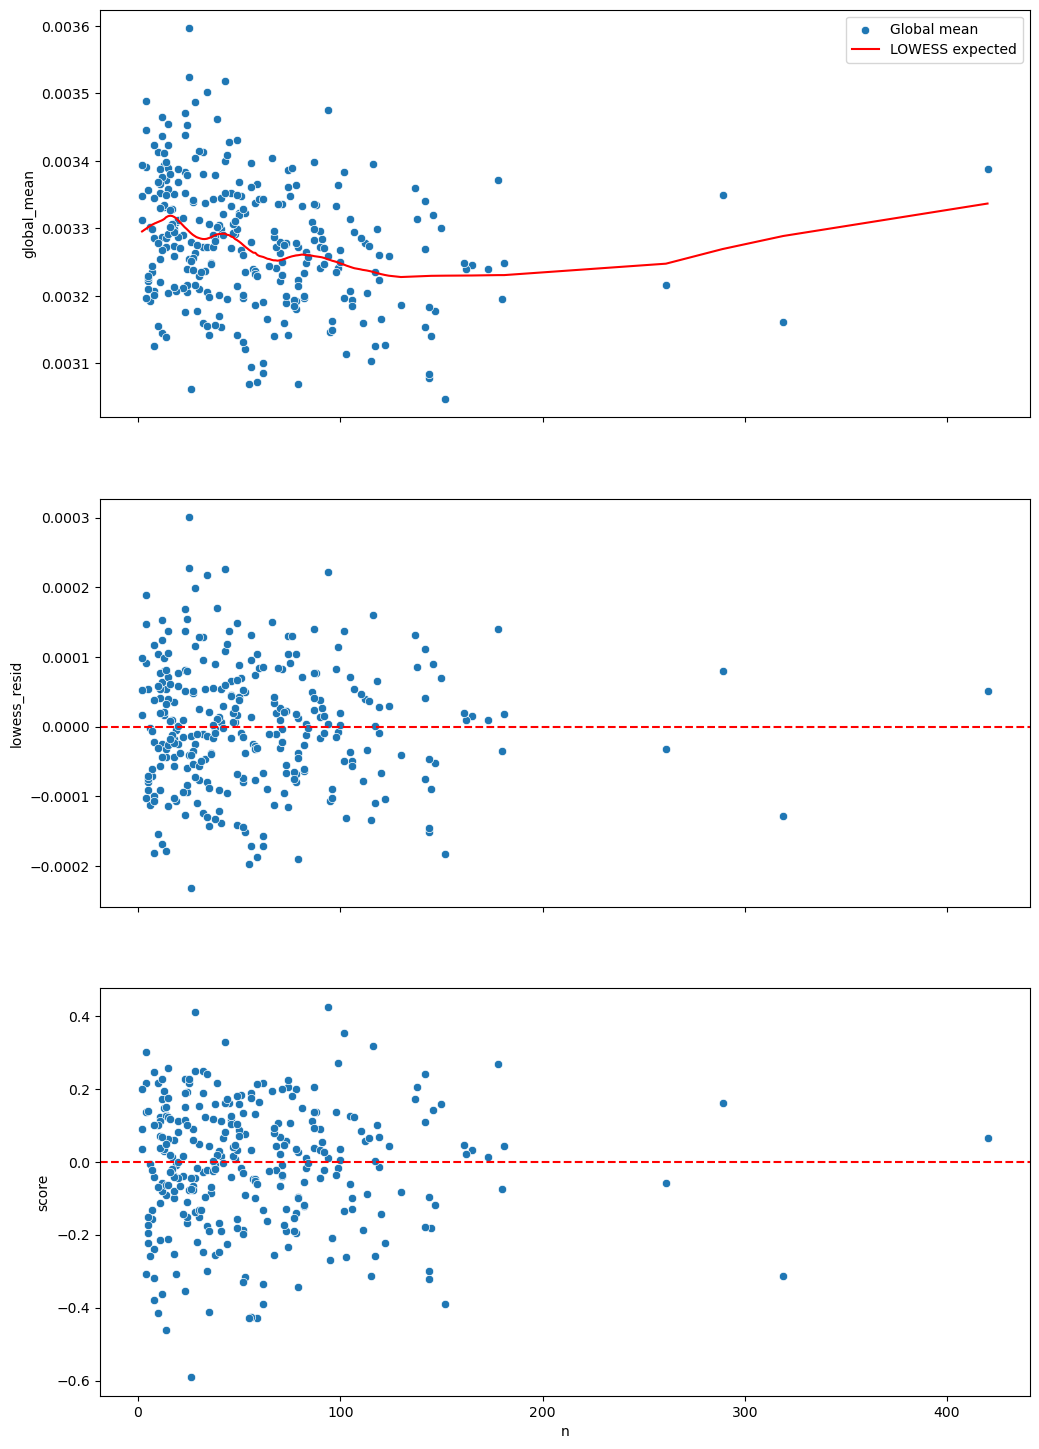

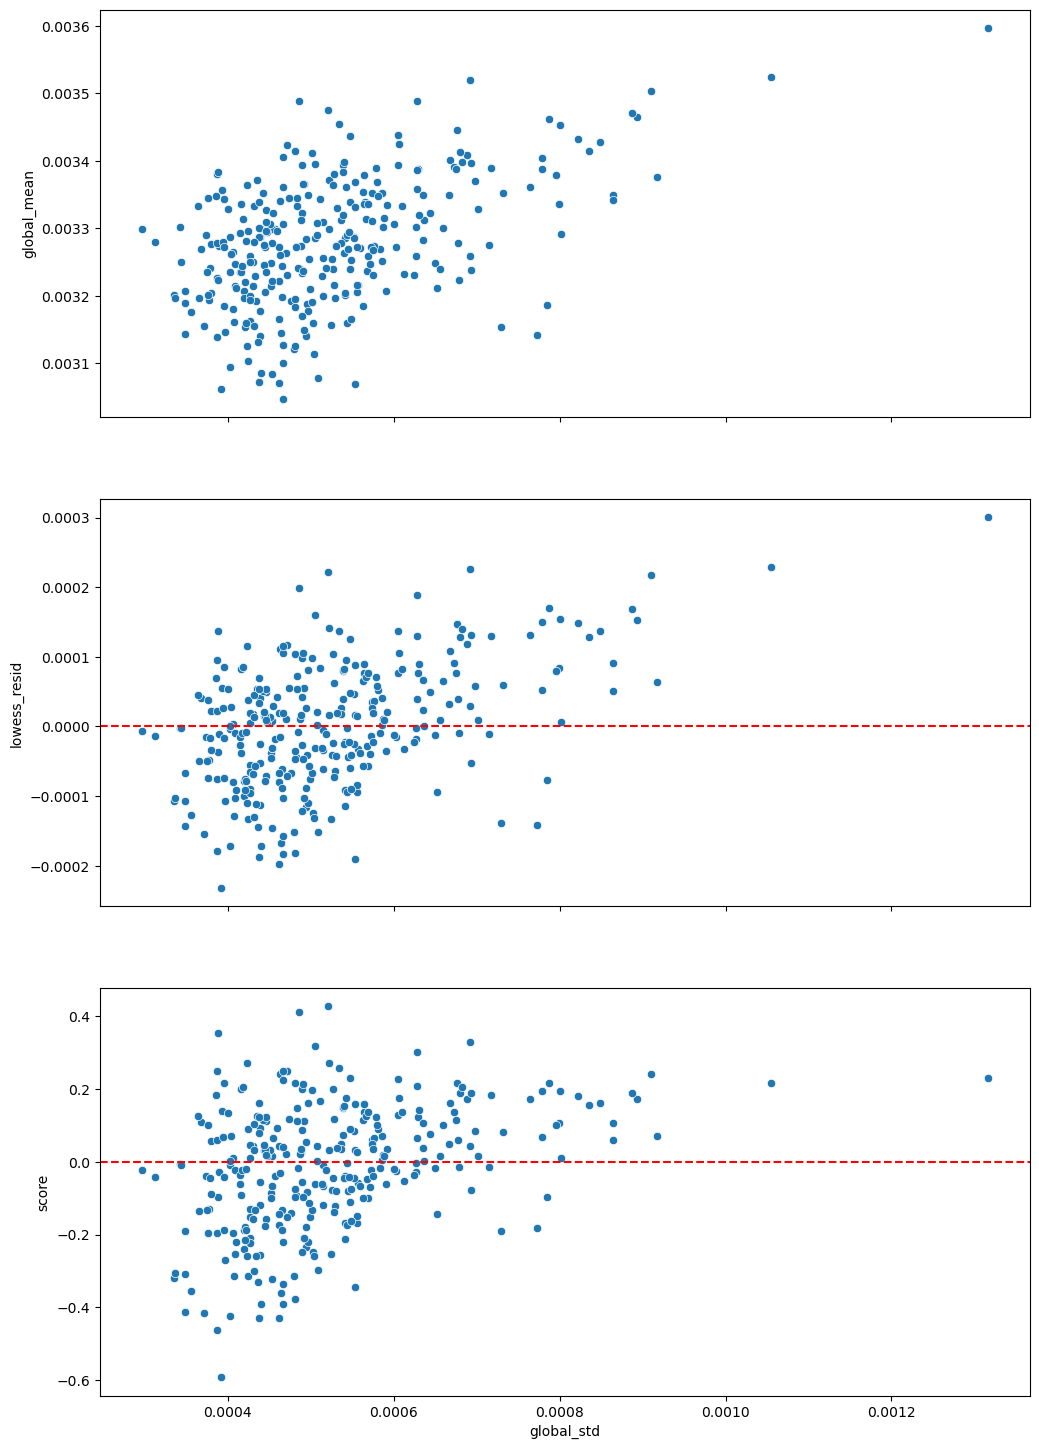

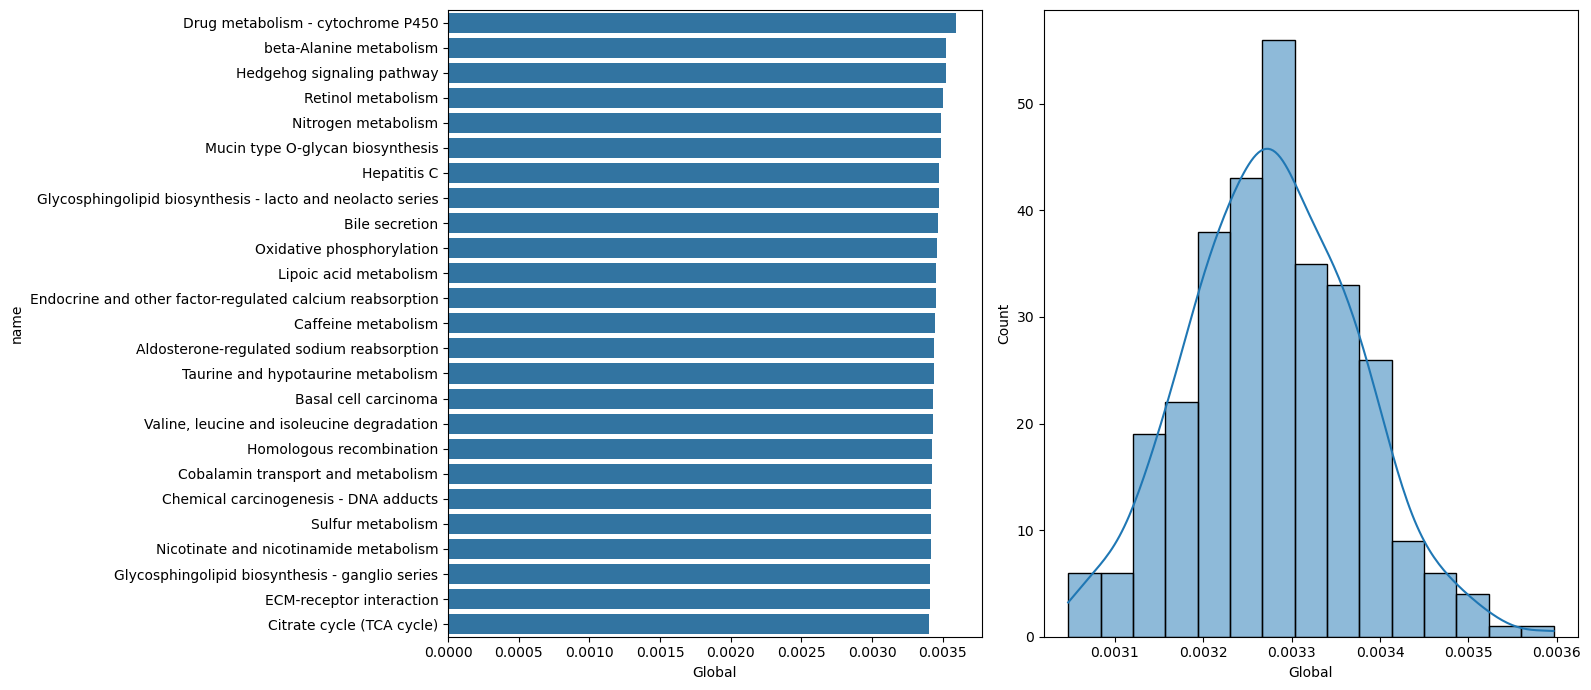

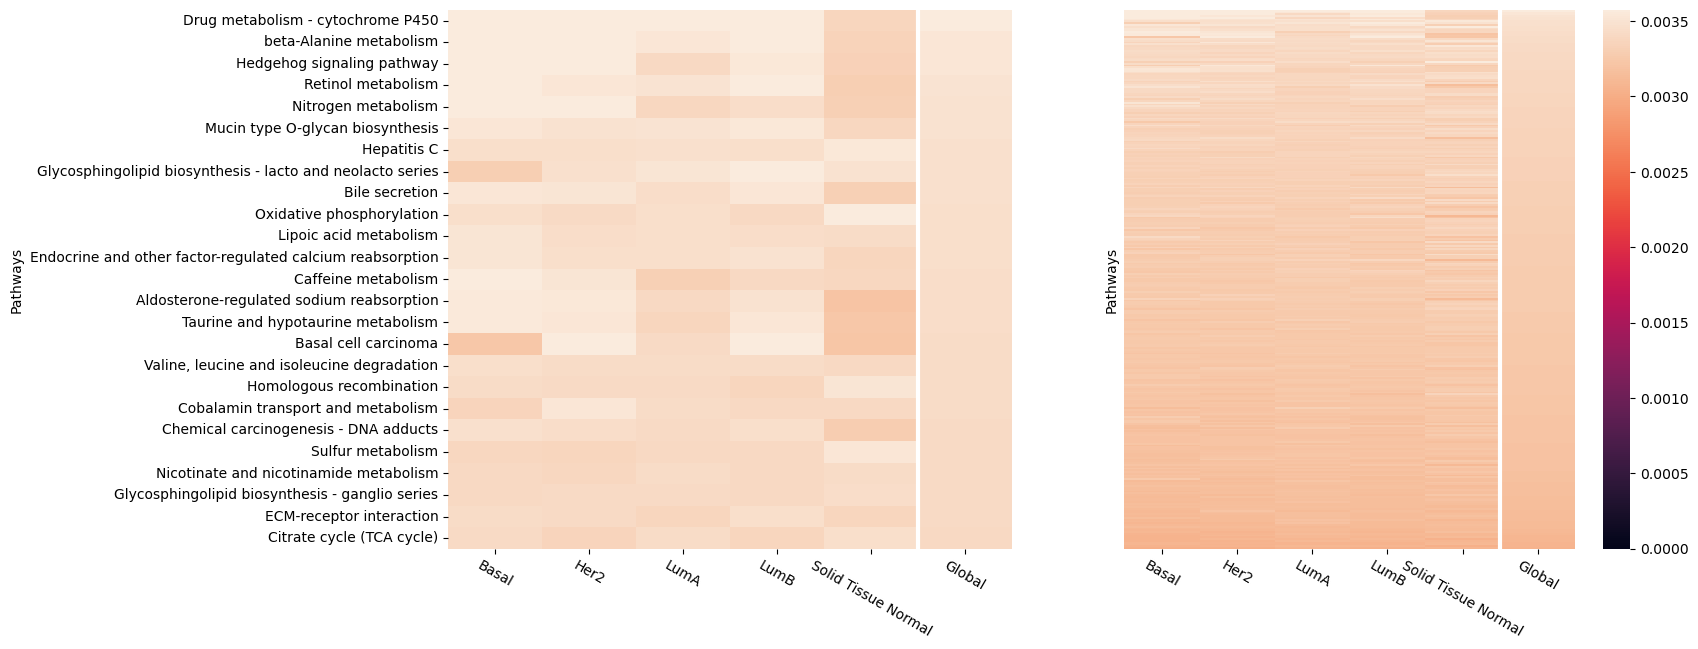

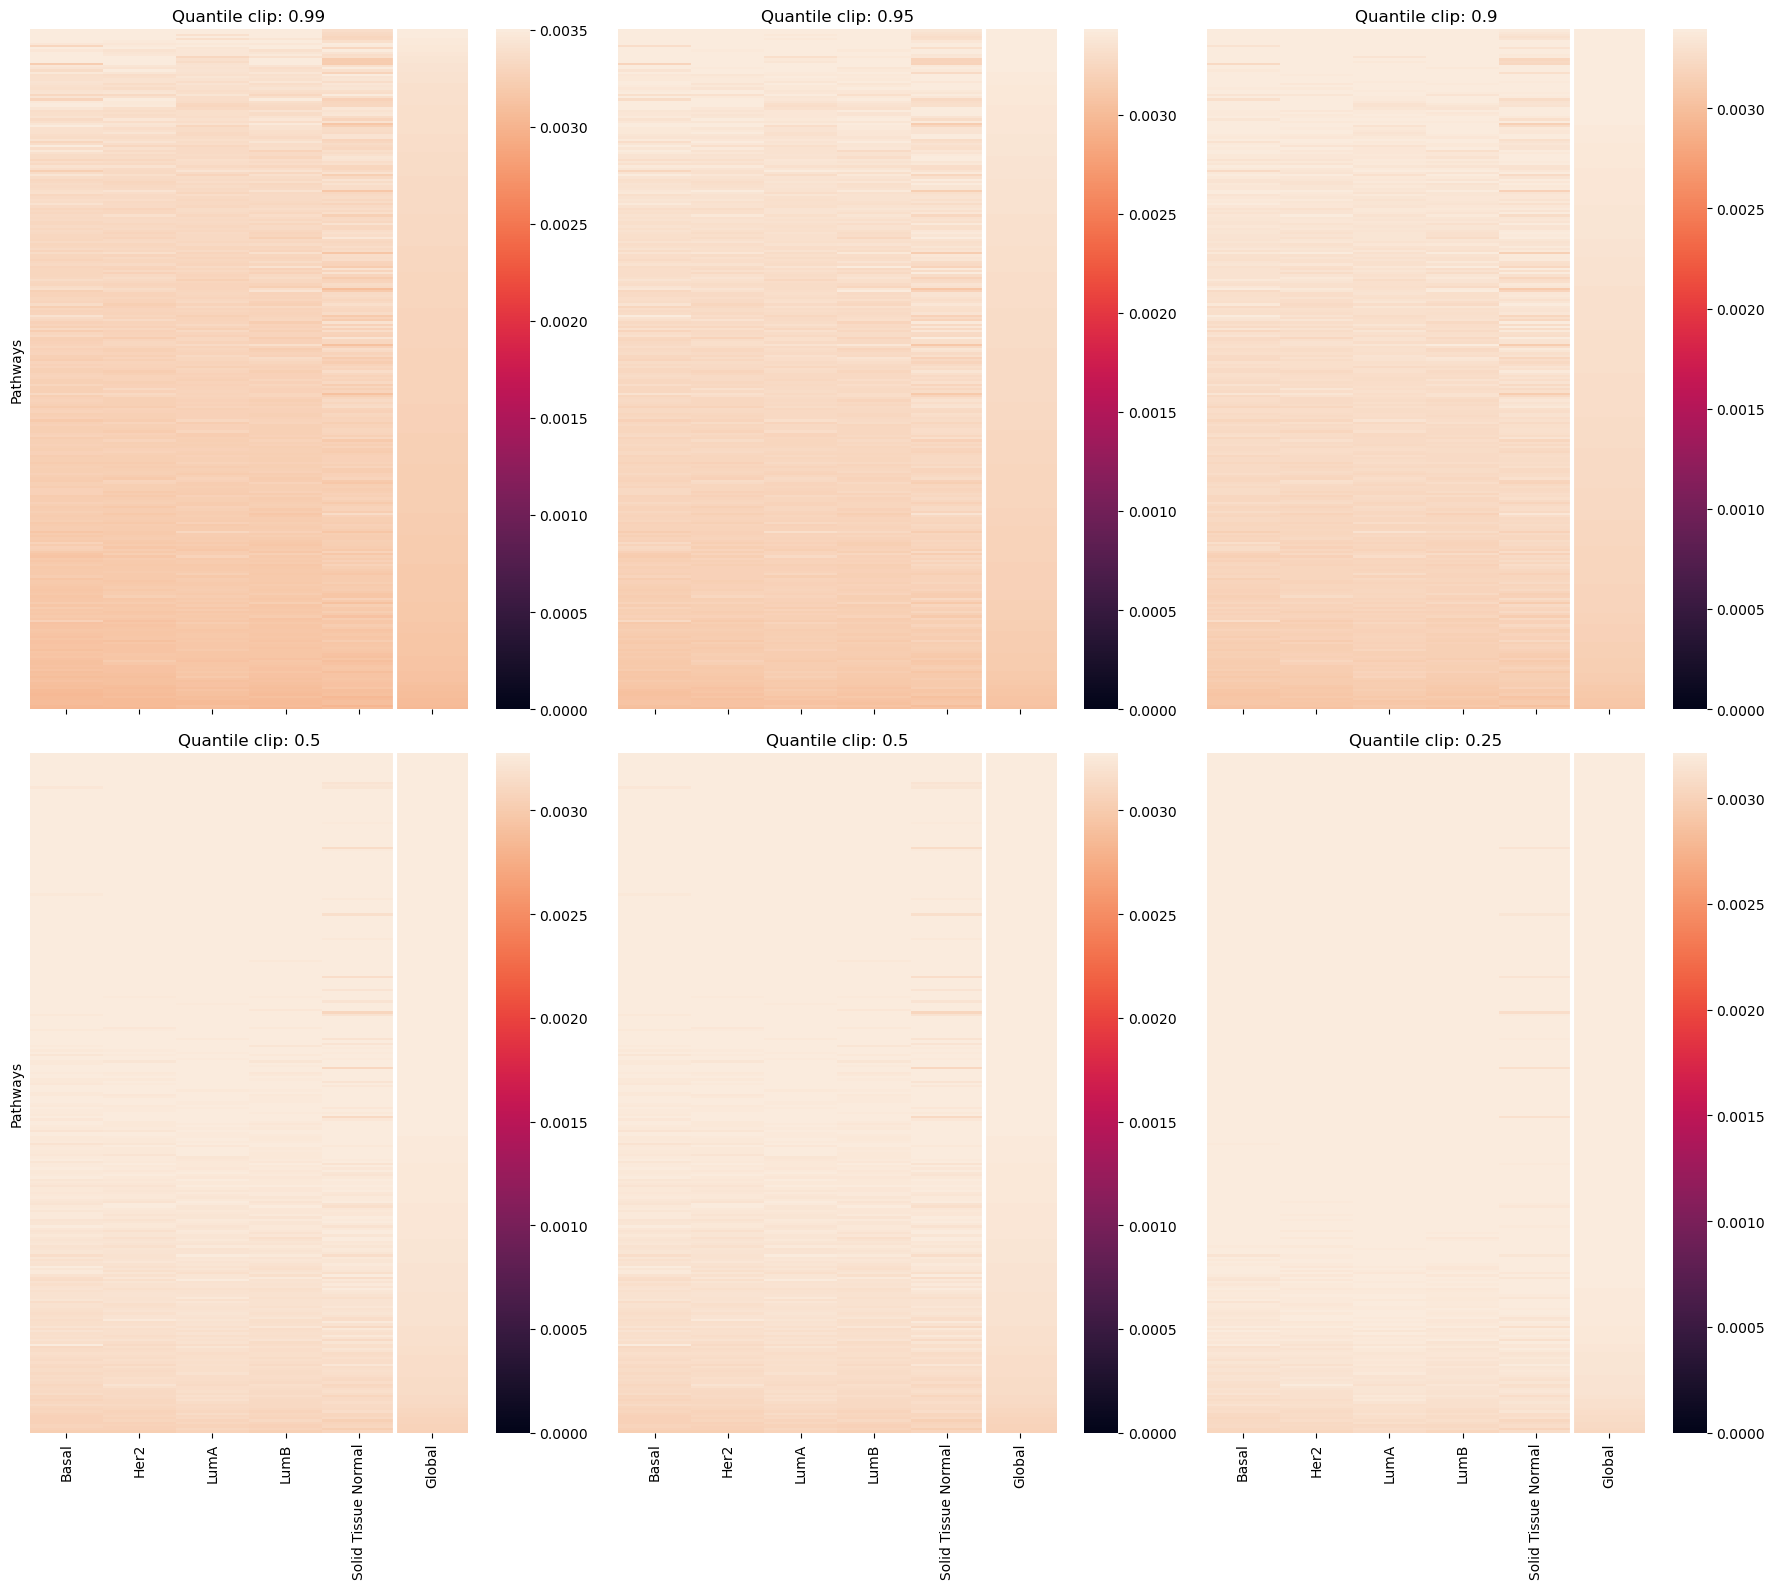

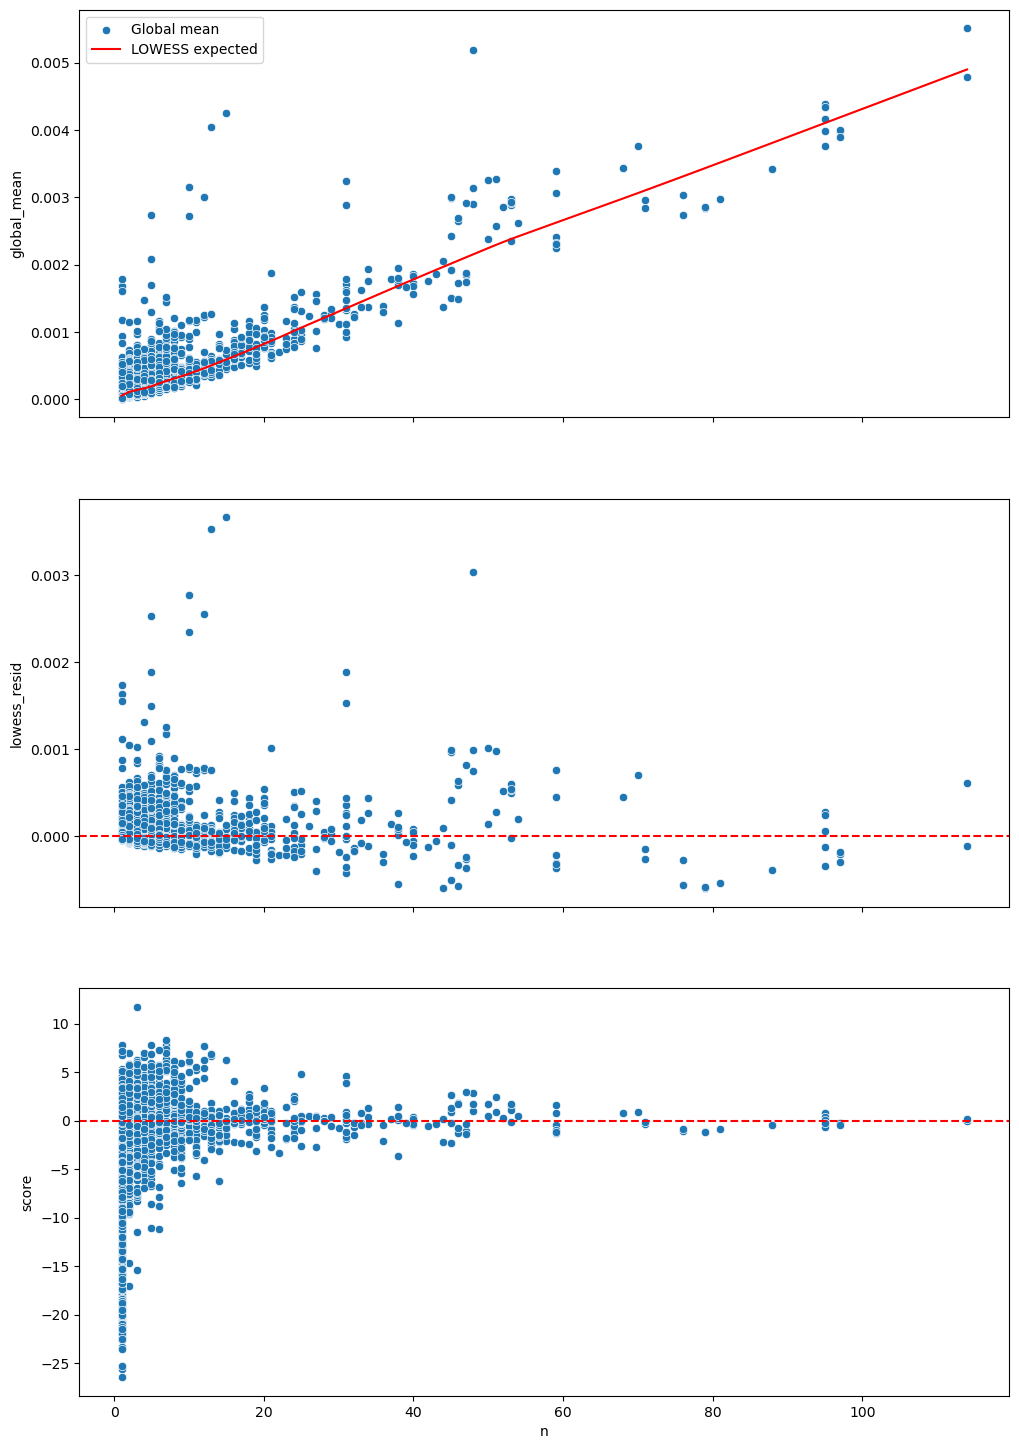

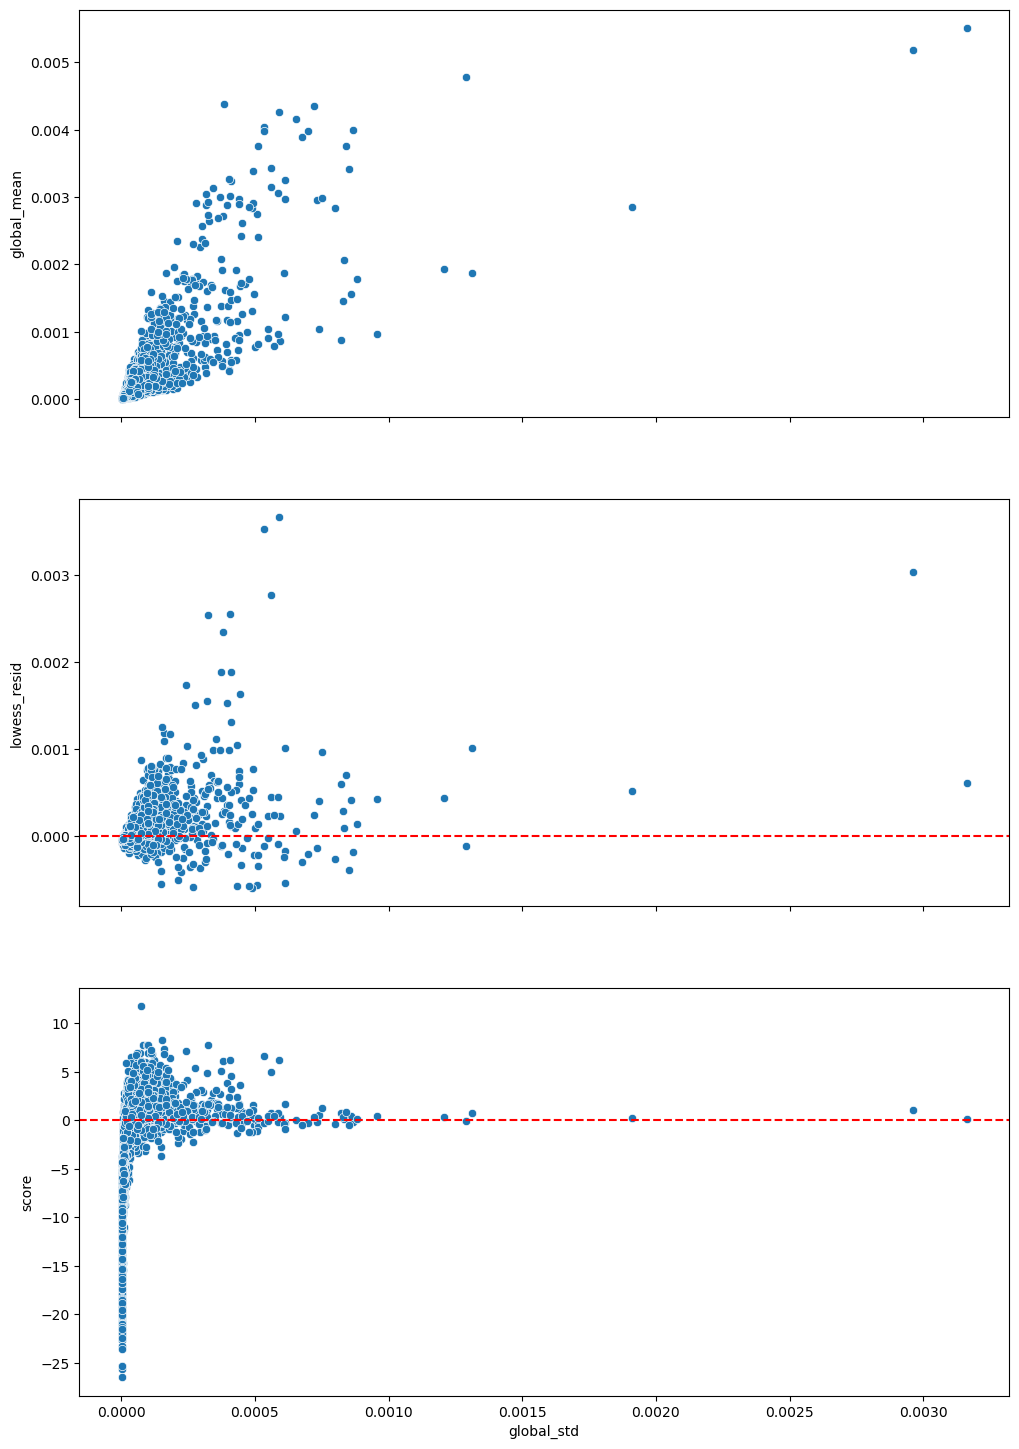

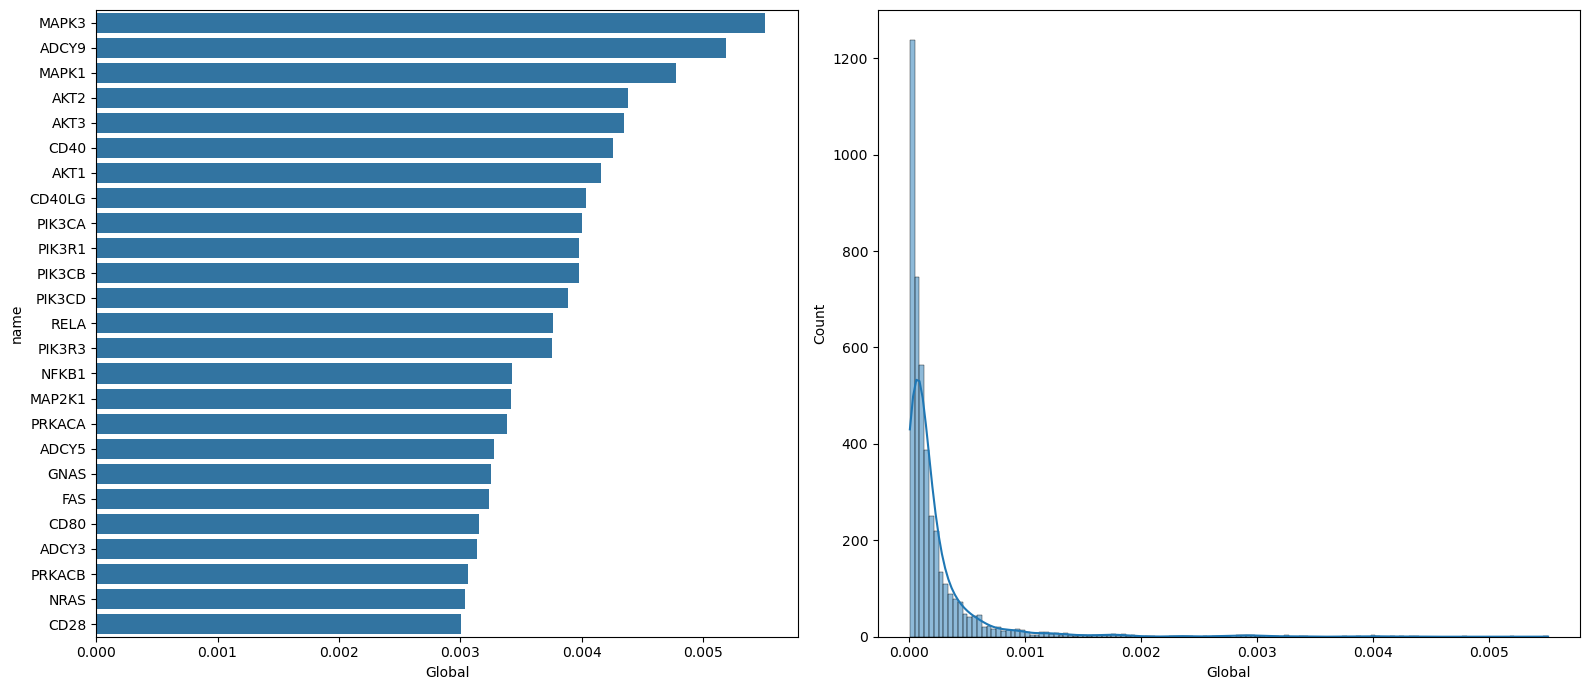

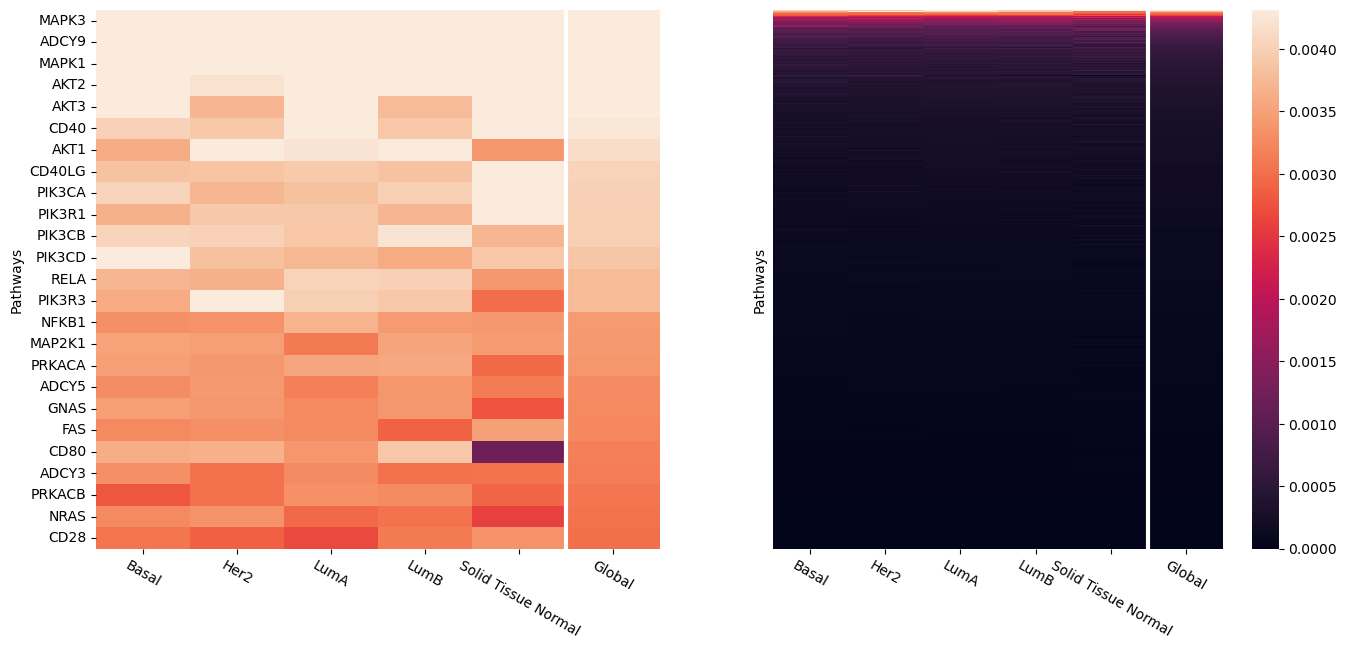

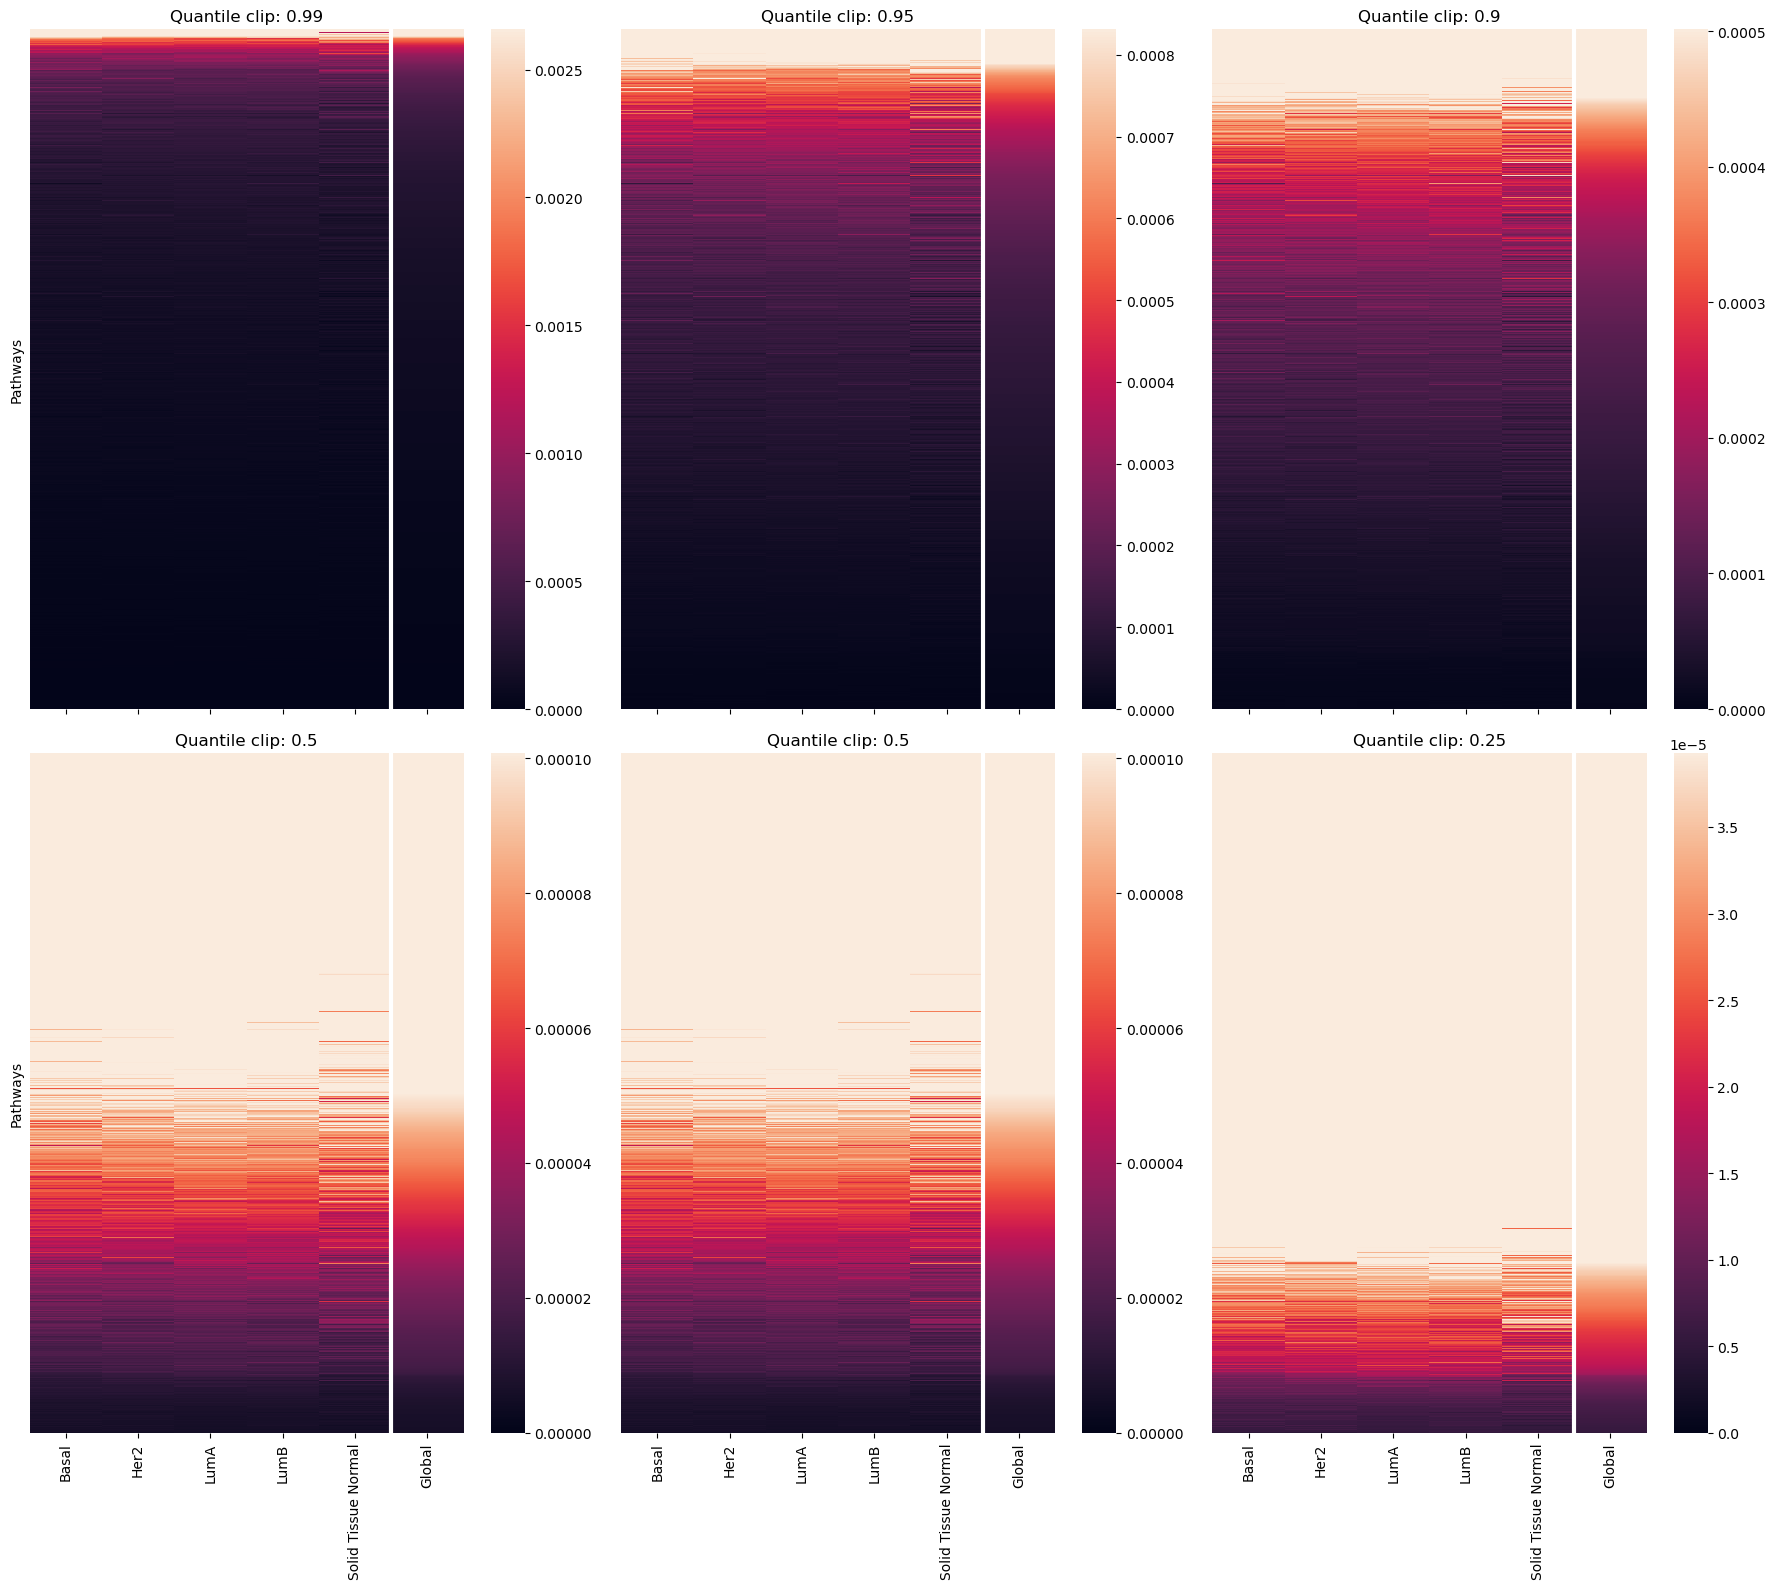

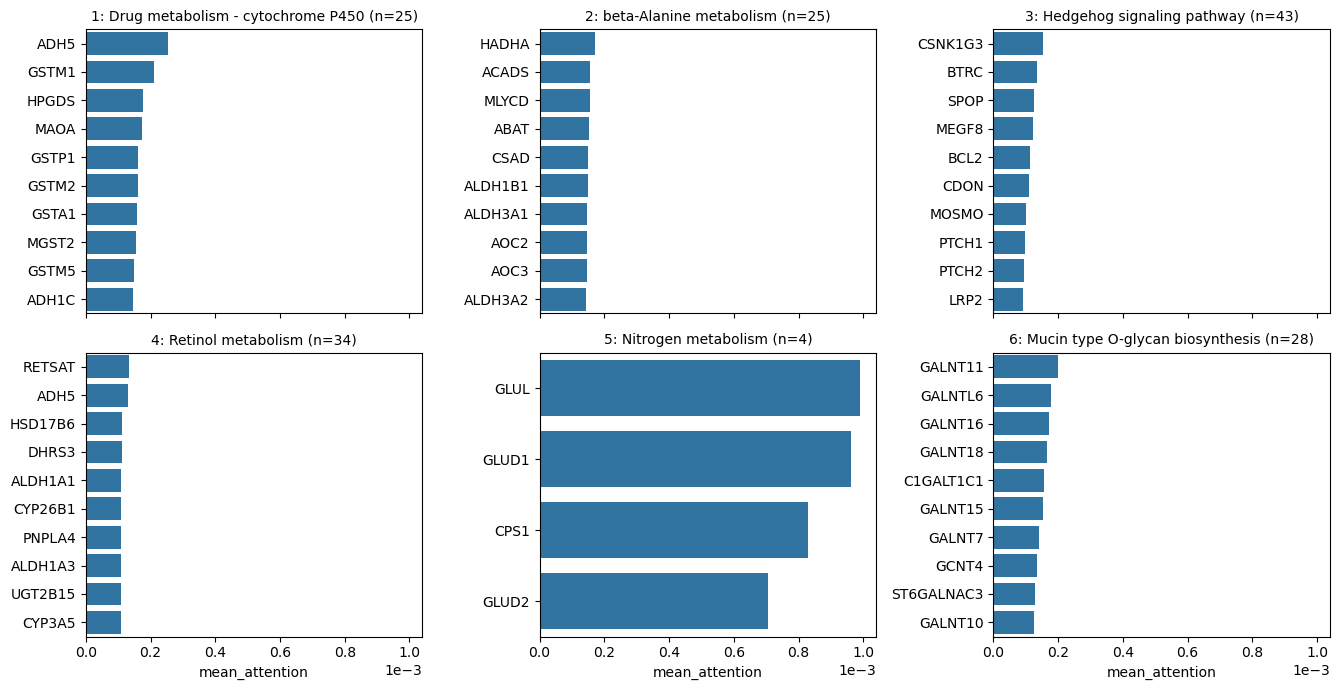

In [22]:
ae.generate_task_plots(level='pathway', top_k_pathways=25, on='global_mean')
ae.generate_task_plots(level='gene', top_k_pathways=25, on='global_mean')
ae.generate_joint_plots(10, 6, on='global_mean')

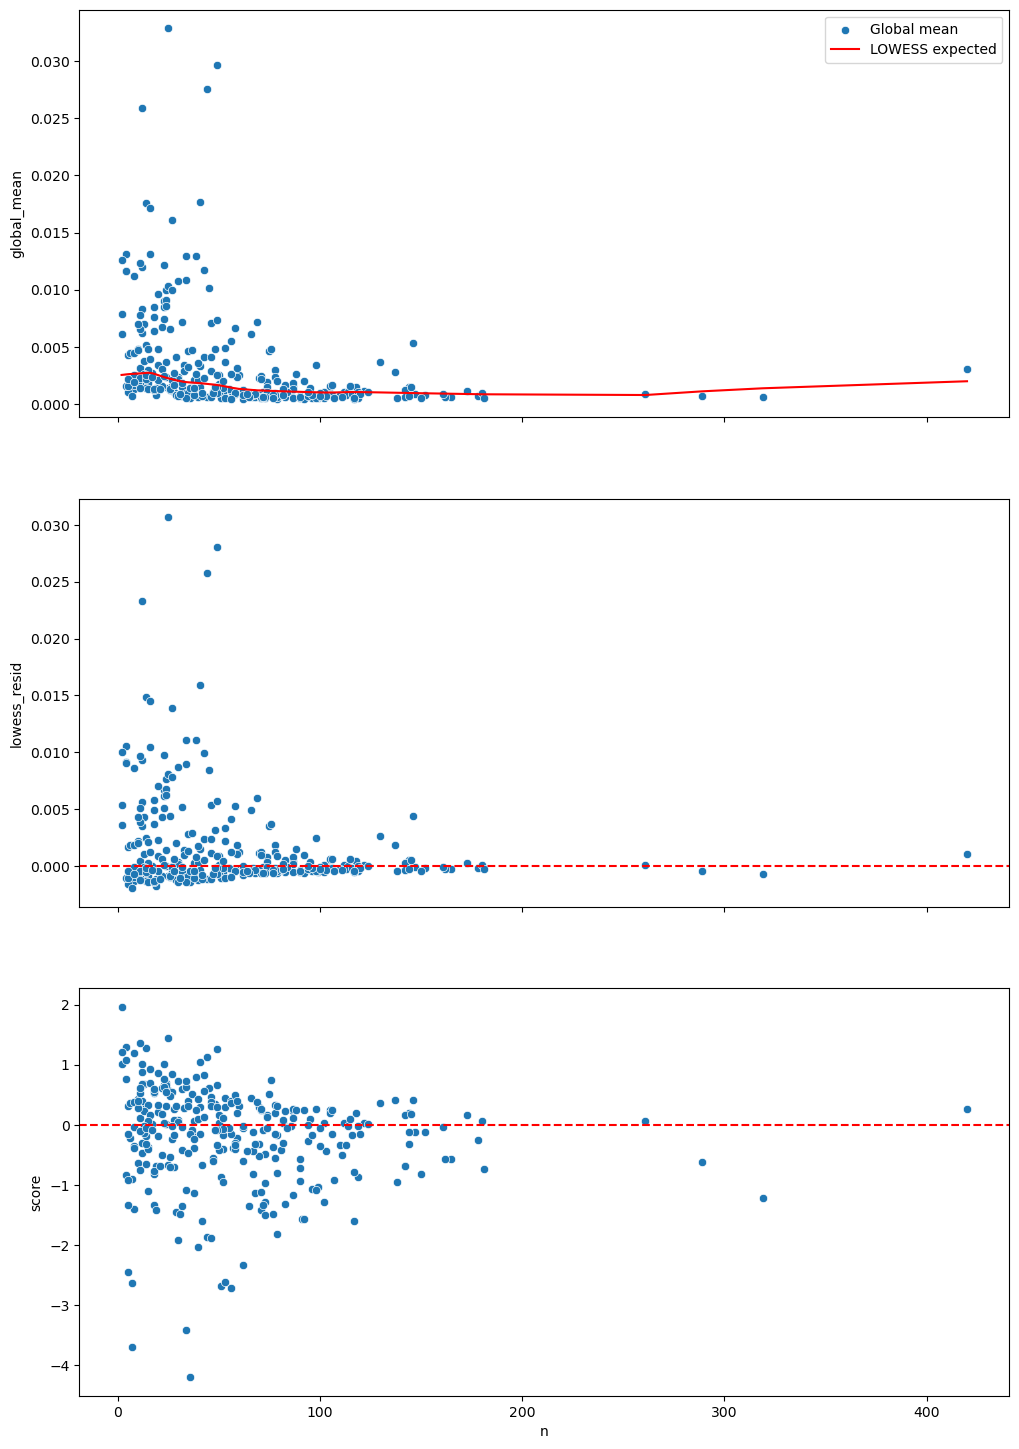

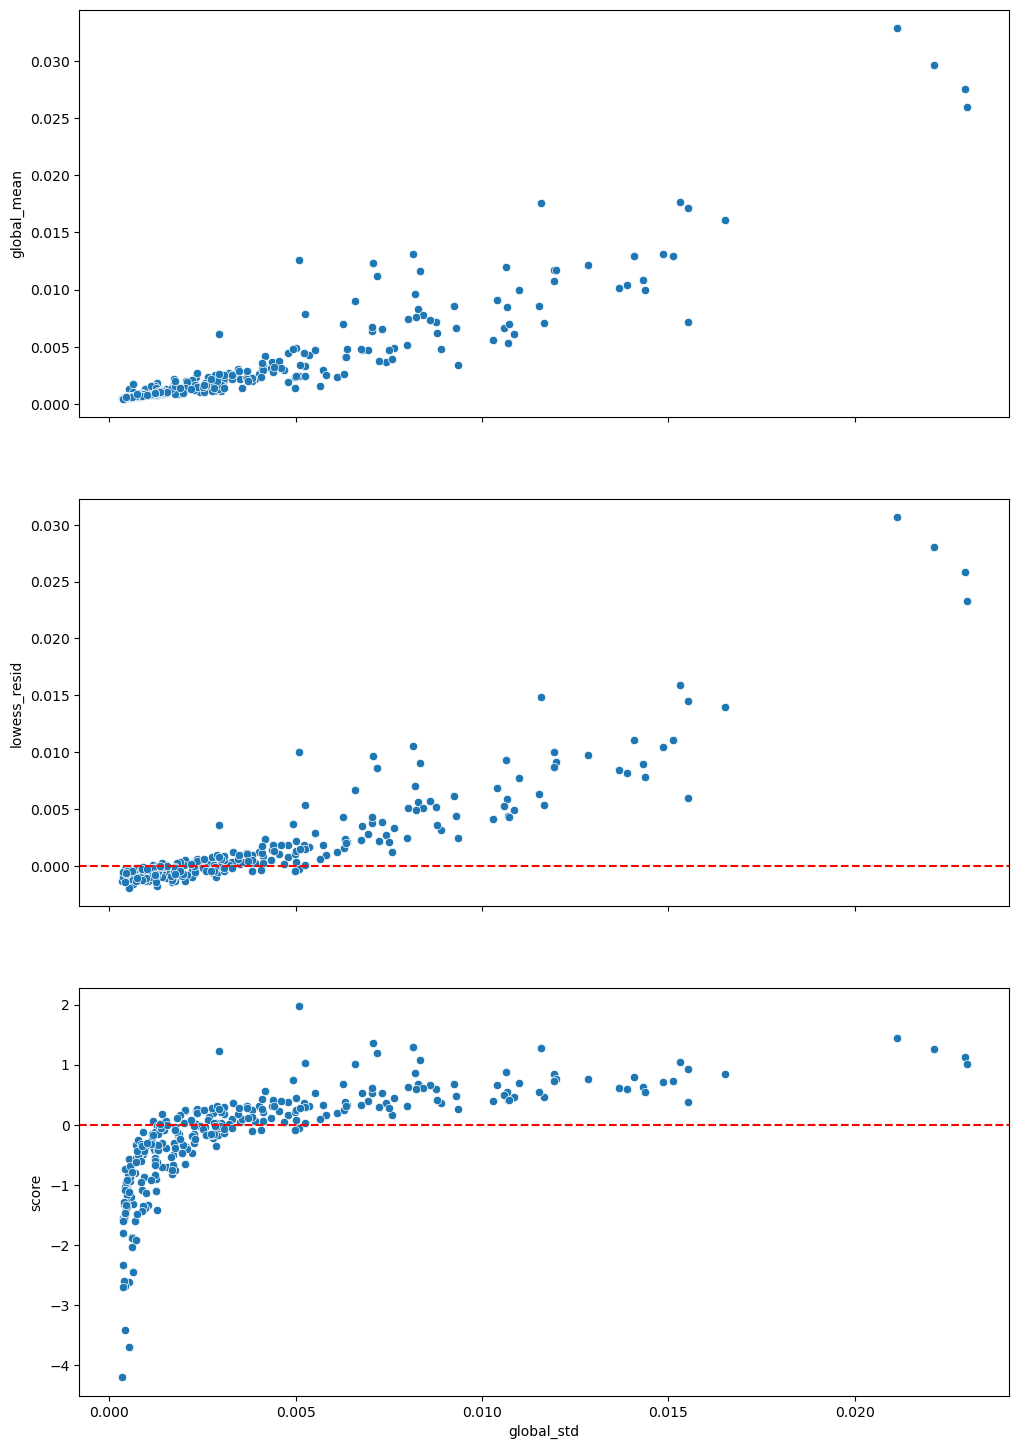

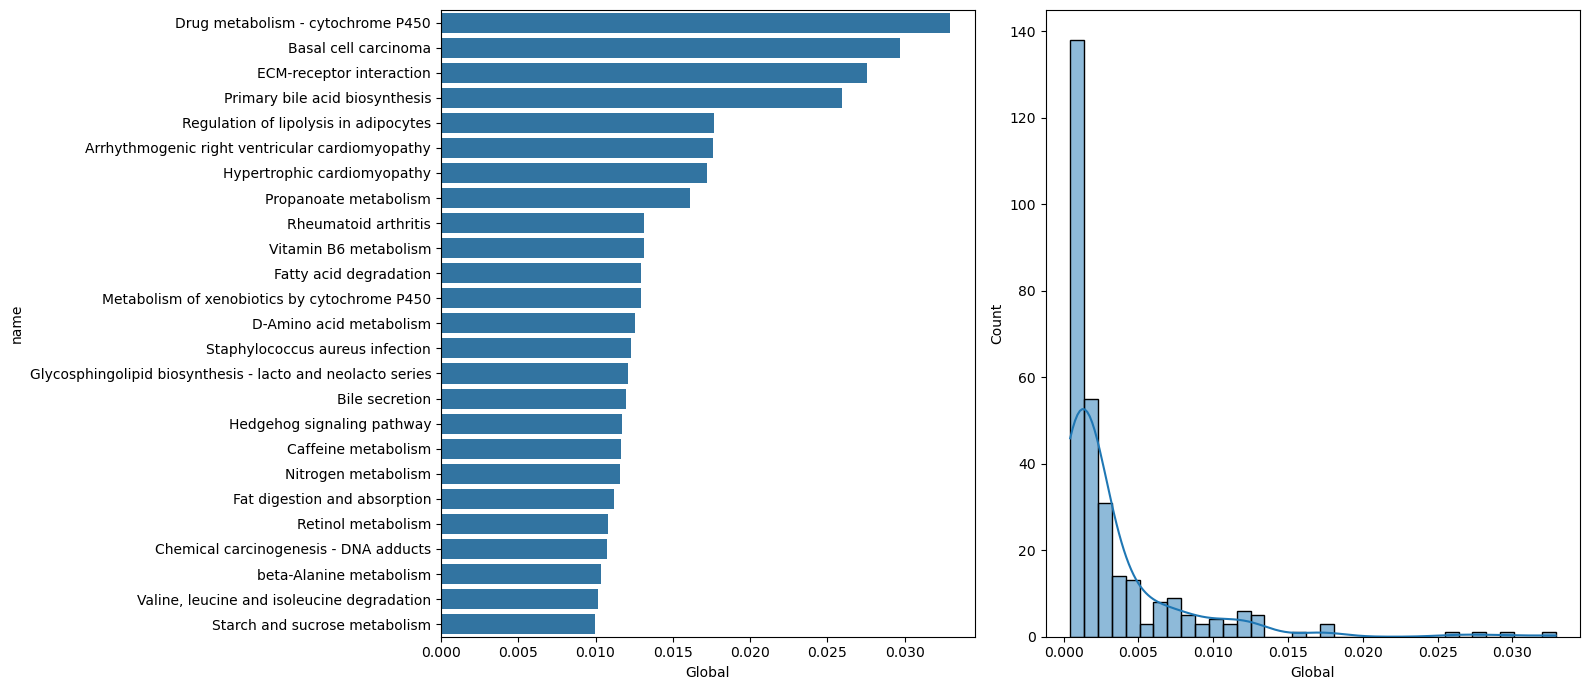

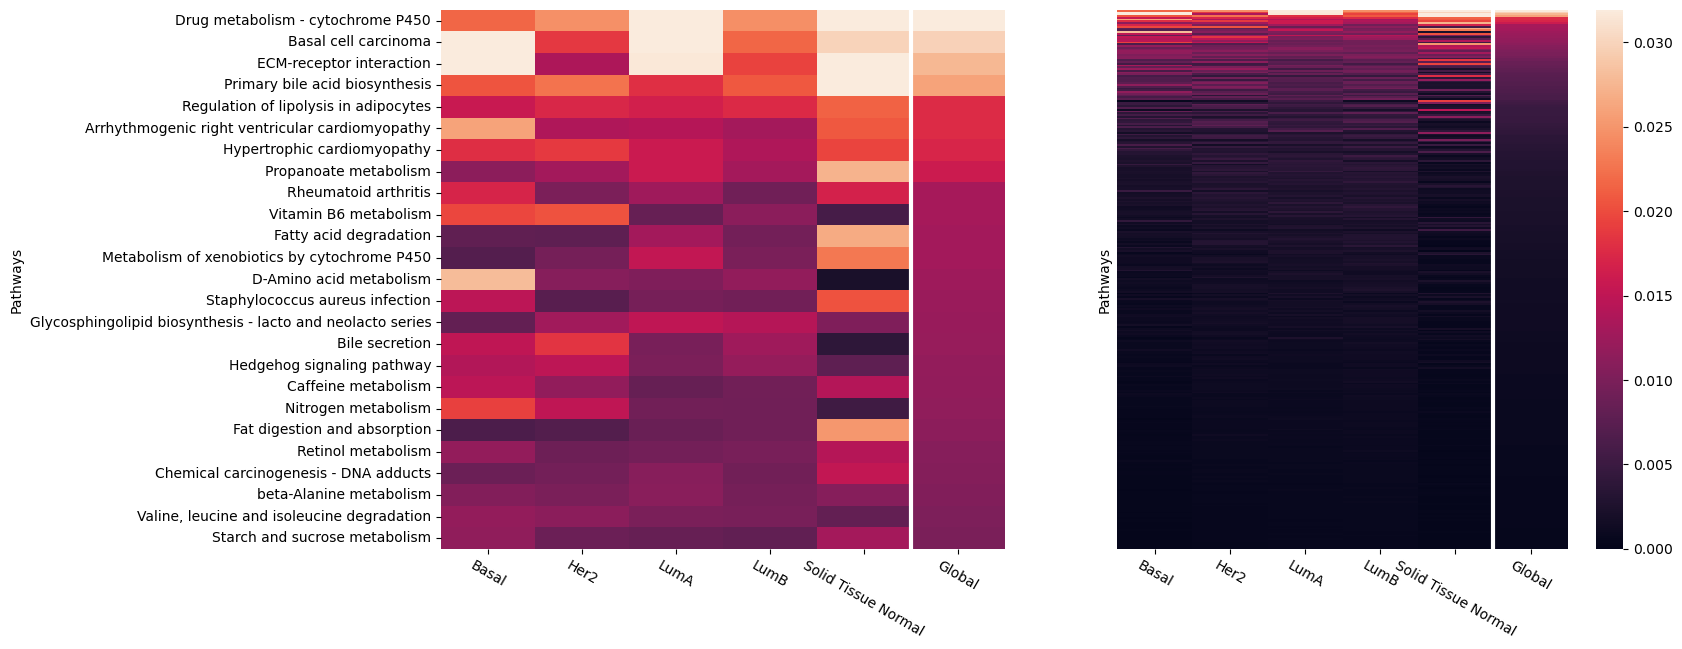

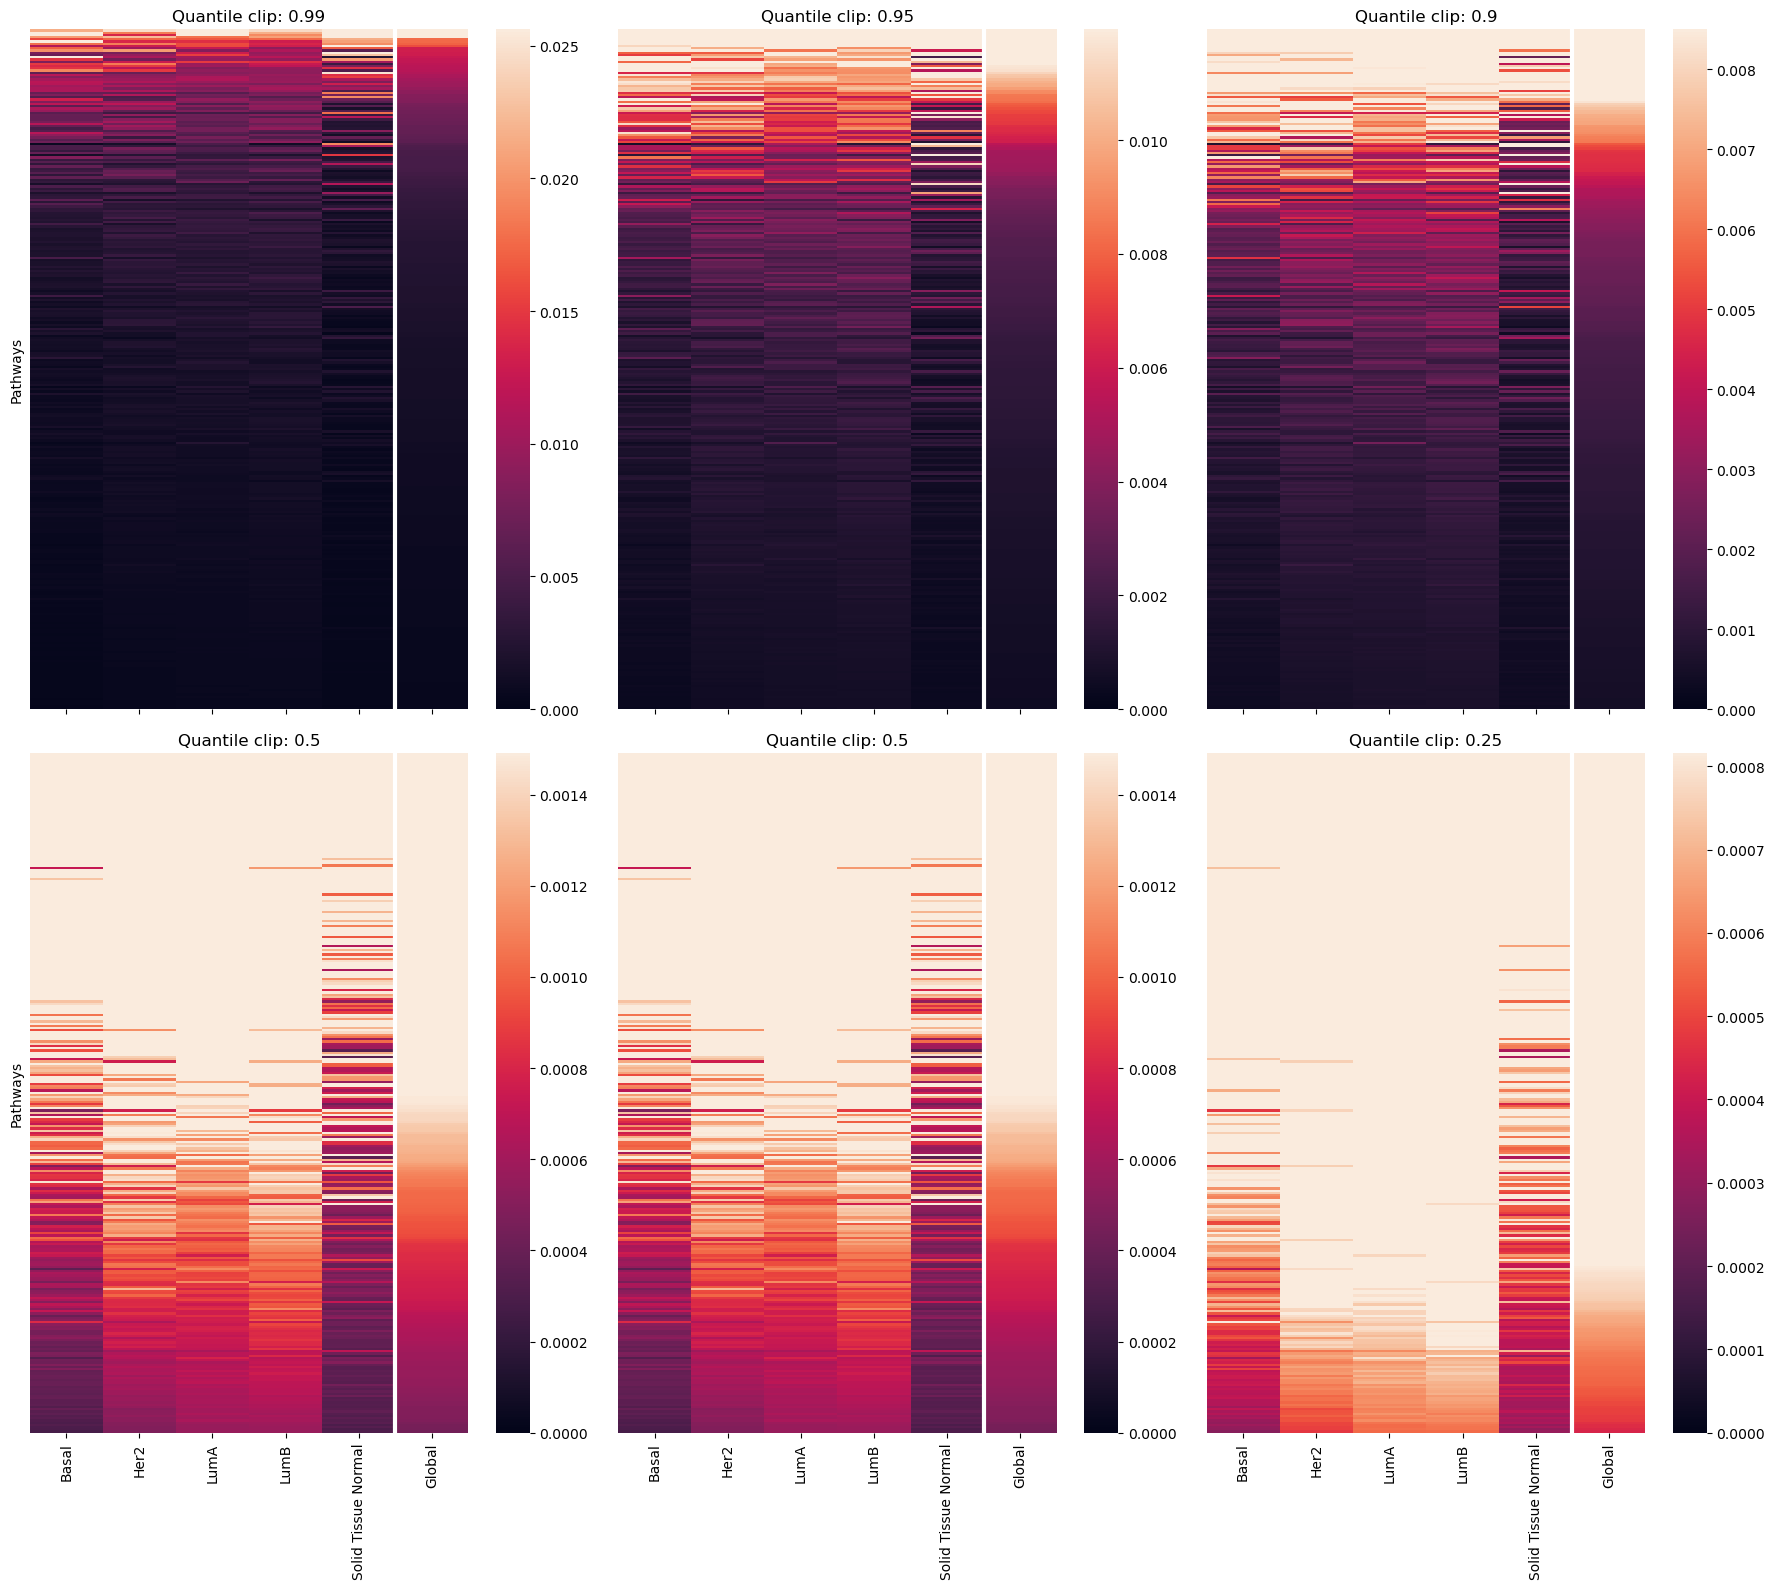

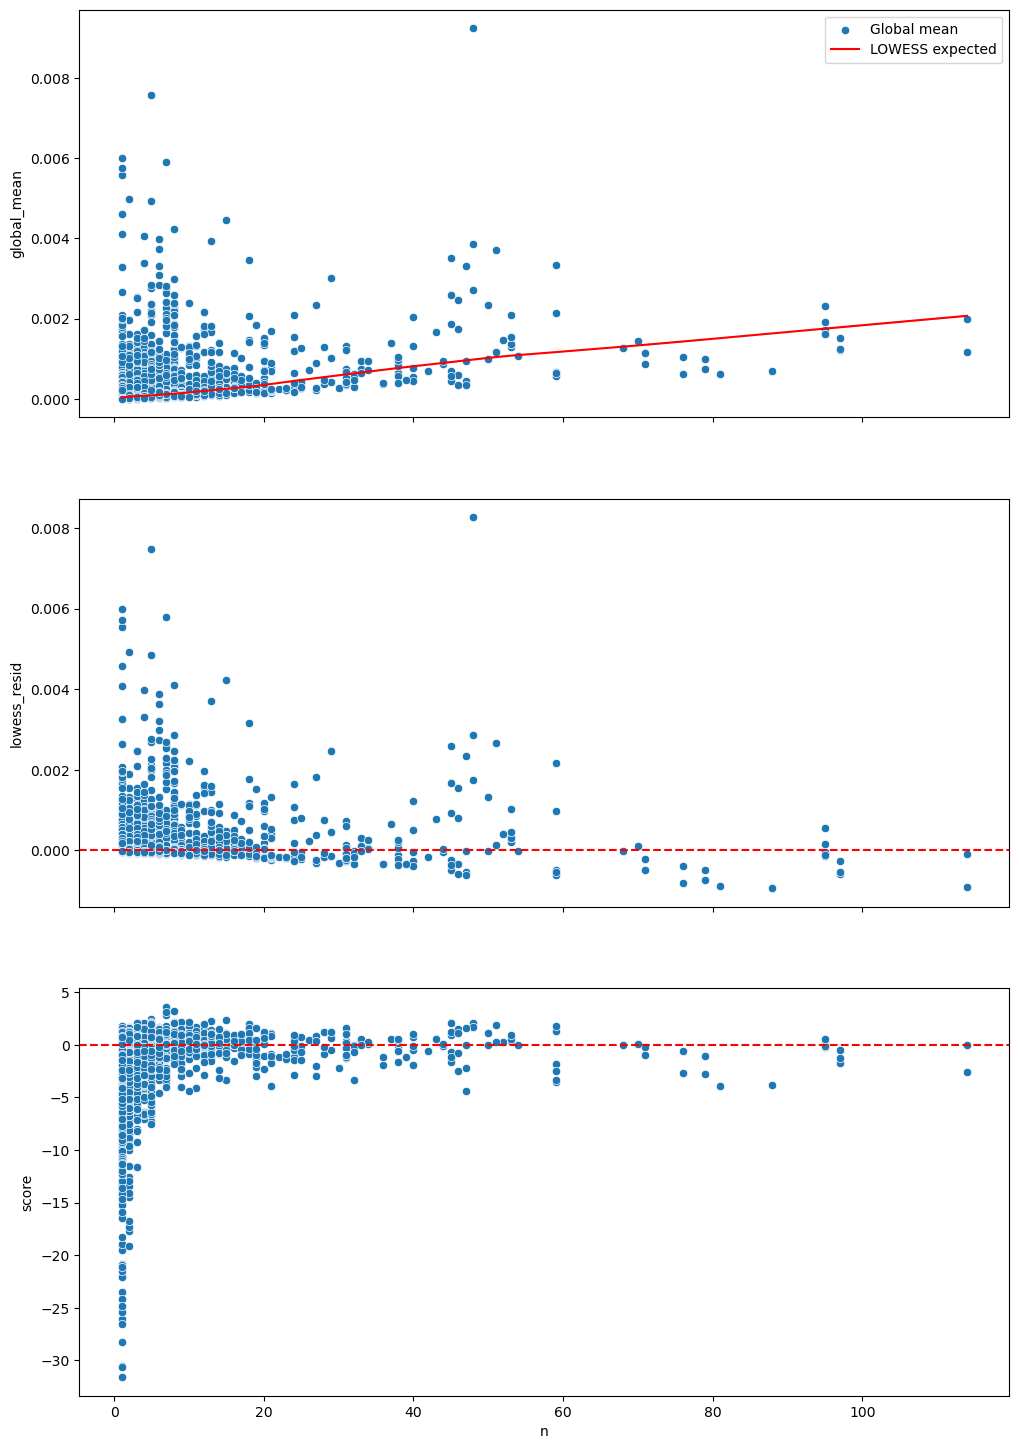

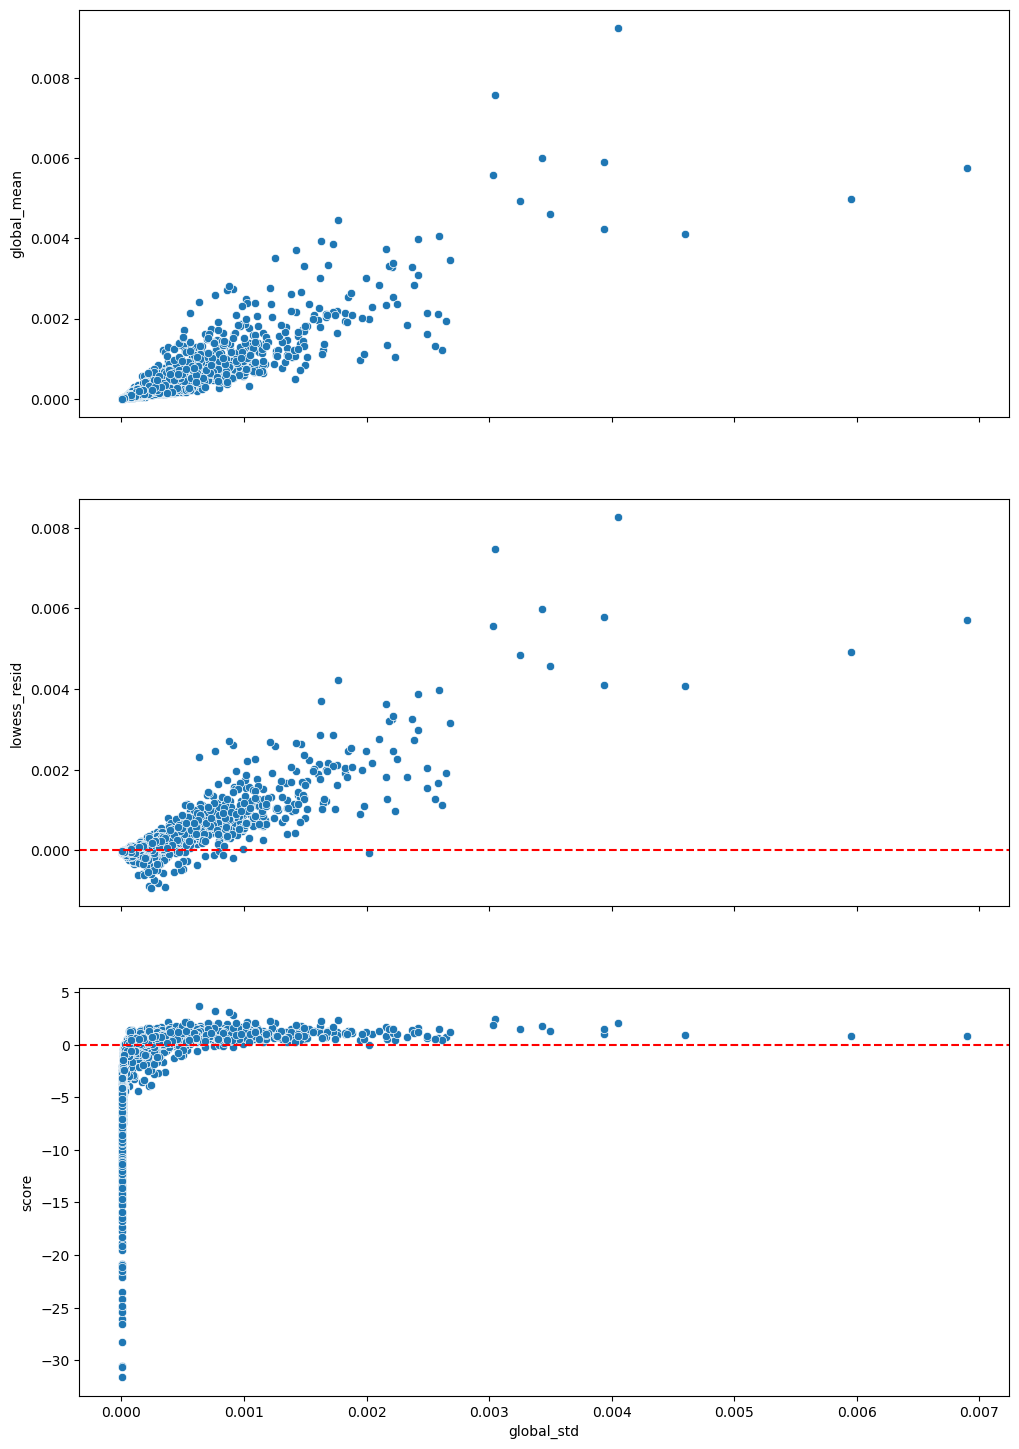

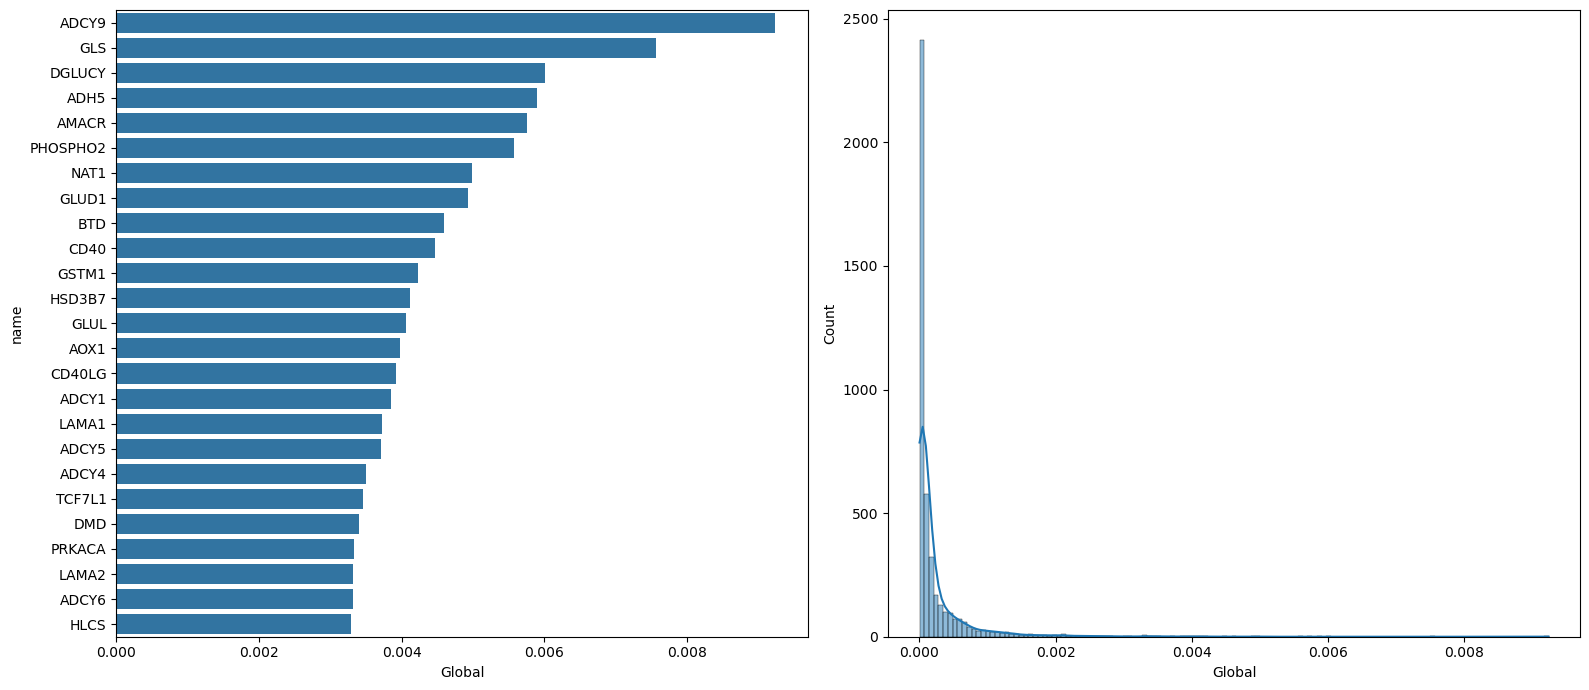

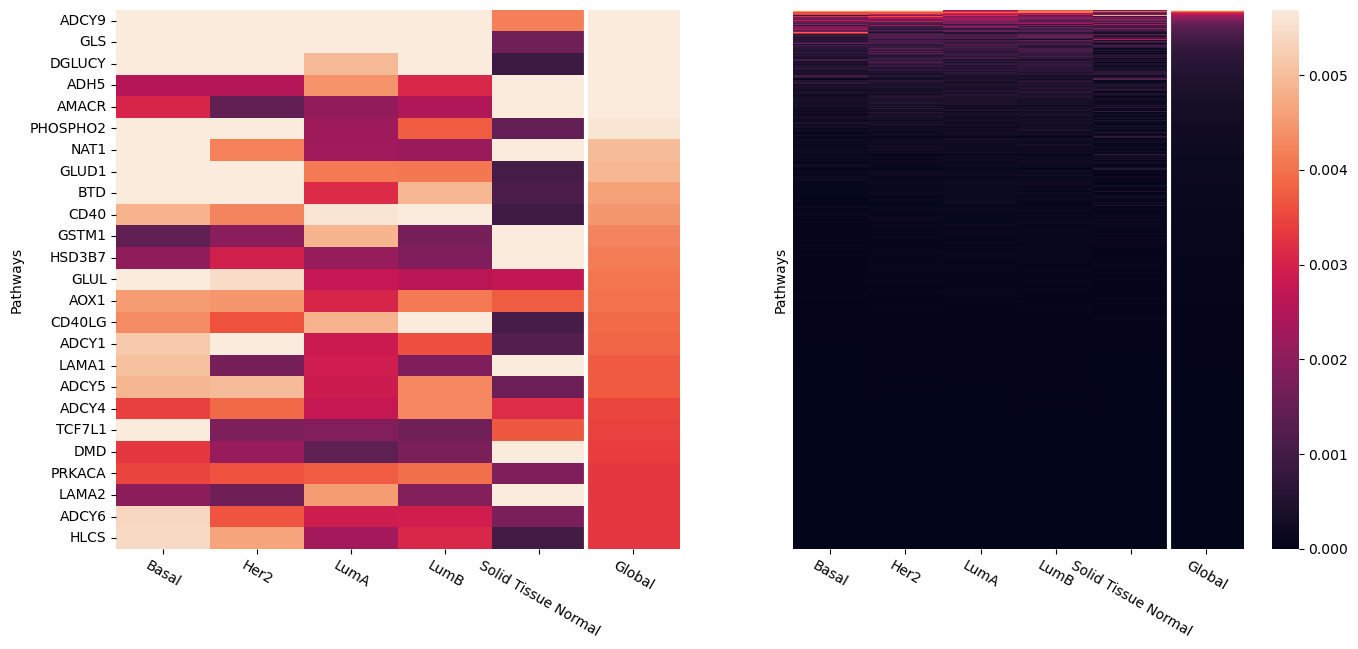

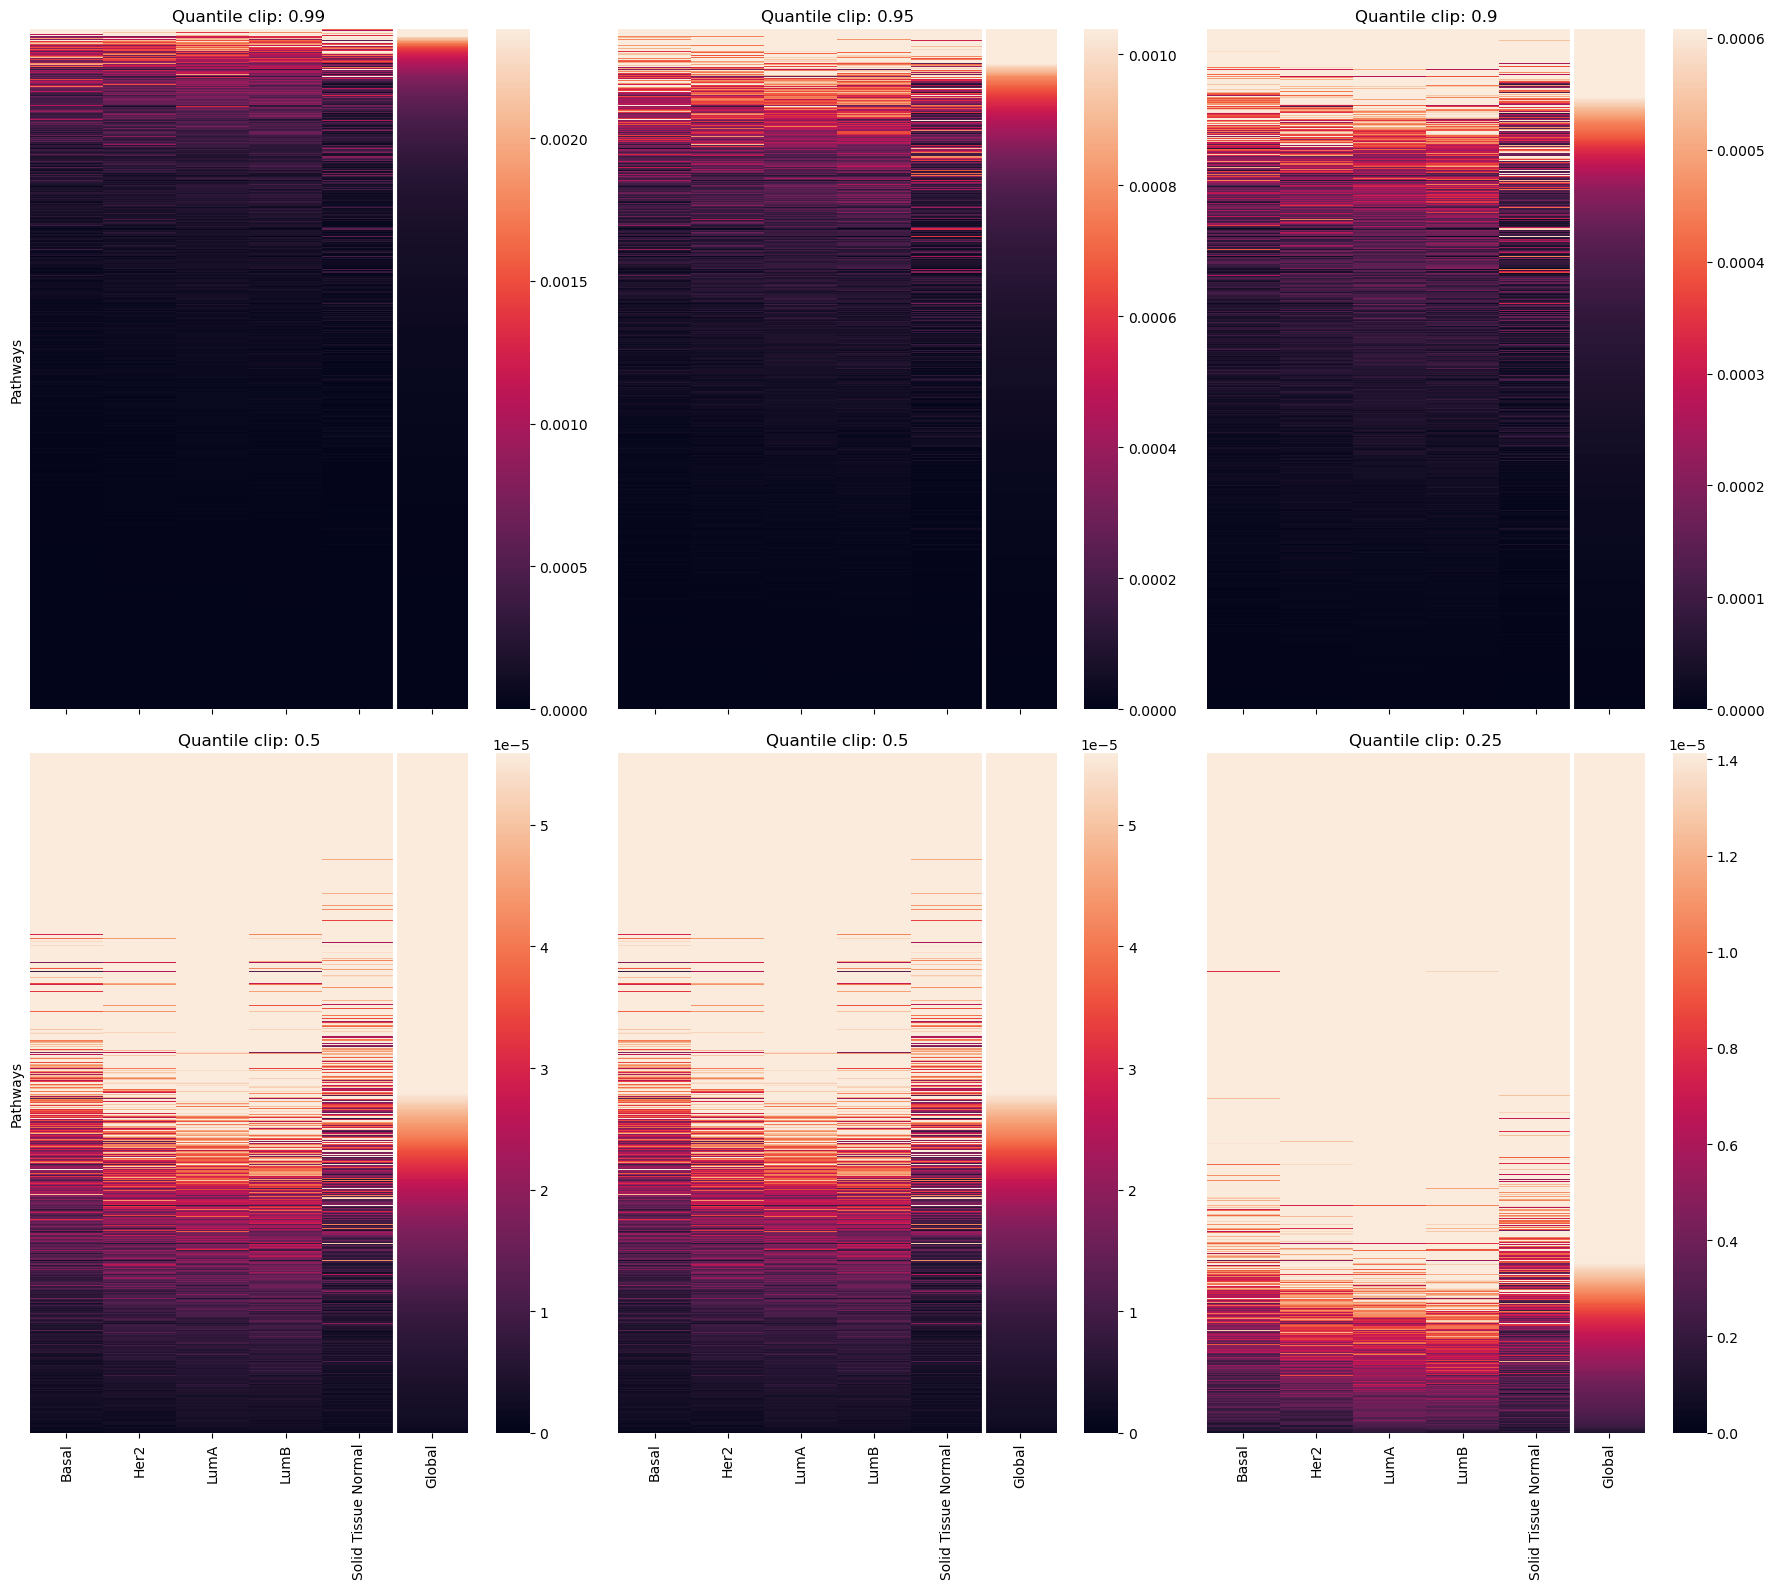

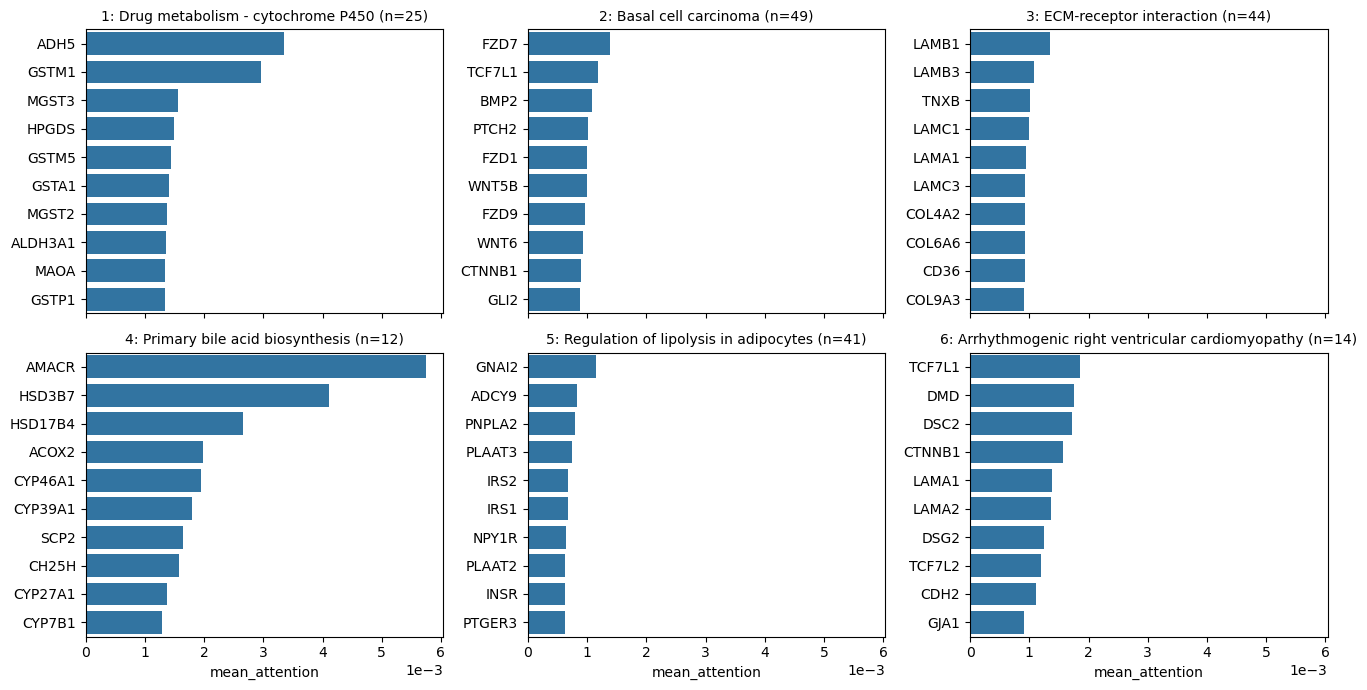

In [23]:
cl.generate_task_plots(level='pathway', top_k_pathways=25, on='global_mean')
cl.generate_task_plots(level='gene', top_k_pathways=25, on='global_mean')
cl.generate_joint_plots(10, 6, on='global_mean')